In [1]:
# %matplotlib ipympl
import os
# import ipympl
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
import matplotlib.patches as mpatches
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
import seaborn as sns
import cupy as cp  
import time
from scipy.interpolate import RectBivariateSpline, RegularGridInterpolator
from scipy.integrate import simpson 
from scipy.stats import linregress
from ipywidgets import interact, IntSlider
from matplotlib.ticker import MaxNLocator
from core import plot_heat_and_surface

In [2]:
#file paths
DATA_DIR = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_10"

#files for longitudinal estimation
SIM_FILES_Longitudinal_Estimation = {
    "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\t_array.csv",
    "freq": r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\delz_MHz.csv",
    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_0\transHport_t_vs_Bz_delx_0.01_dely_0.1.csv"
}

#files for y field estimation 
SIM_FILES_CONFIG_Y_Estimation = {
    "time": os.path.join(DATA_DIR, "t_array.csv"),
    "freq": os.path.join(DATA_DIR, "delz_MHz.csv"),
    "by_vals": os.path.join(DATA_DIR, "dely_MHz.csv"),
    # MUST be in the same order as By_values.csv
    "intensities": sorted([
        os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("transH_t_vs_Bz_alpha2500_delx_0_dely_") and f.endswith(".csv")
    ], key=lambda x: float(x.split("_dely_")[1].split(".csv")[0]))
}
#FIXME this is for the data from 13/02
'''EXP_FILES ={
    "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\t_array_.csv",
    "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\Y_MHz.csv",
    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\Bx_V_Readout.csv"
}'''

#FIXME 26/03 => By_0 = -0.104761771731084 Mhz
EXP_FILES ={
    "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\t_array_ Copy.csv",
    "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_Y_MHz.csv",
    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_V_Readout_By_0.csv"
}

# EXP_FILES ={
#     "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\t_exp.csv",
#     "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Y_MHz_Exp.csv",
#     "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv"
# }

# EXP_FILES ={
#     "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Dummy_1\t_array.csv",
#     "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Dummy_1\delz_MHz.csv",
#    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Dummy_1\transH_t_vs_Bz_alpha2500_delx_0_dely_0.1.csv"
# }

# Test = "1_Mar_New_Exp_Data"
# new_dir = f"Tests/Actual/CW/Test_{Test}"
# new_dir_y = f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}"
# os.makedirs(new_dir, exist_ok=True)
# os.makedirs(new_dir_y, exist_ok=True)

<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_26308\4142462645.py:23: SyntaxWarning: invalid escape sequence '\D'
  "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\t_array_.csv",


In [3]:
#z field estimation parameters
#Convert to Gauss -> 0.7 MHz ~ 1 Gauss
#z field estimation parameters
B_UNK_BOUND = 1
B_UNK_INITIAL_RANGE = (-B_UNK_BOUND, B_UNK_BOUND) 
INITIAL_RESOLUTION  = 0.0005
SIGMA_NOISE_LONGITUDINAL = 0.05
SIGMA_NOISE_TRANSVERSE = 0.1

#y field estimation parameters
FIXED_BZ_ESTIMATE = 0.05
FIXED_BY_ESTIMATE = 0.18
b_y_bounds = (0.0,0.5)
initial_res_by = 0.0001

F_BIAS_OFFSET_NUISANCE = 0
#pulse on threshold, need to align both  the  graphs to t=0
SIM_PULSE_THRESH = 0.3
EXP_PULSE_THRESH = 0.3

In [4]:
#Adaptive experiment parameters
T_STEP = 0.2
MAX_TIME = 70 
KL_Y_GRID_SIZE = 200 #number of points under consideration for KL divergence expectation over hypothetical signal

In [5]:
ZOOM_FACTOR = 1.1
ZOOM_TRIGGER_RATIO = 0.2
global ZOOM_TRIGGER_MULTIPLE
ZOOM_TRIGGER_MULTIPLE = 400

In [6]:
#Data loading and pre-processing
def find_pulse_start(trace, t_axis, threshold):
    idx = np.where(trace>threshold)[0]
    if len(idx)>0:
        return t_axis[idx[0]], idx[0]
    return t_axis[0], 0

# def load_simulation(files):
#     to = time.time()
#     print(f"Loading Simulation from {files['data']}...")
#     t = pd.read_csv(files['time'], header = None).values.flatten()
#     f = pd.read_csv(files['freq'], header  = None).values.flatten()
#     d = pd.read_csv(files['data'], header = None).values

#     if d.shape != (len(t),len(f)):
#         d = d.T

#     d= calibration(d, 0, 1)
#     spline = RectBivariateSpline(t, f, d, kx = 1, ky = 1)
#     print(time.time()-to, "was the time taken to load sim data.")

#     return  t,f,spline

#im gonna load the data, find the start, remove that shit and then normalise
def load_simulation_cube(config):
    print("...Loading Simulation Cube Data...")
    to = time.time()
    t_axis = pd.read_csv(config['time'], header=None).values.flatten()
    f_axis = pd.read_csv(config['freq'], header=None).values.flatten()
    by_axis = pd.read_csv(config['by_vals'], header=None).values.flatten()

    print(f"  > Axes Loaded: Time[{len(t_axis)}], Freq[{len(f_axis)}], By[{len(by_axis)}]")

    t_sim_0, _ = 0.0,0
    matrix_list = []
    for fname in config['intensities']:
        data =  pd.read_csv(fname, header=None).values

        if data.shape != (len(t_axis), len(f_axis)):
            data = data.T
        #plot_heat_and_surface(t_axis, f_axis, data)
        if len(matrix_list) == 0:
            scale = 1/(np.max(data)-np.min(data))
            calibrated_data = (data-np.min(data))*scale
            calibrated_data = np.clip(calibrated_data, 0.0, 1.0)
            t_sim_0, _ = find_pulse_start(calibrated_data[:,0], t_axis, SIM_PULSE_THRESH)
            # print(_)

            t_axis_0 = t_axis[_:] - t_sim_0

        # print(data.shape)
        data = data[_:,:]
        #plot_heat_and_surface(t_axis_0, f_axis, data)
        # print(data.shape)
        scale = 1/(np.max(data)-np.min(data))
        calibrated_data = (data-np.min(data))*scale
        calibrated_data = np.clip(calibrated_data,  0.0, 1.0)
        #plot_heat_and_surface(t_axis_0, f_axis, calibrated_data)
        matrix_list.append(calibrated_data)
    
    cube = np.stack(matrix_list, axis=2)
    print(f"  > Sim Start: {t_sim_0:.4f}s")
    print(f"  > Cube Built. Final Shape: {cube.shape}")
    print("Time taken to load sim data:", time.time() - to)
    return t_axis_0, f_axis, by_axis, cube

def load_experiment(files, Aligned = False):
    to = time.time()
    print(f"Loading Experiment from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f_bias = pd.read_csv(files['freq_axis'], header  = None).values.flatten()
    raw_data = pd.read_csv(files['data'], header = None).values

    if raw_data.shape != (len(t),len(f_bias)):
        raw_data = raw_data.T

    if not Aligned:
        scale = 1/(np.max(raw_data)-np.min(raw_data))
        calibrated_data = (raw_data-np.min(raw_data))*scale
        calibrated_data = np.clip(calibrated_data,  0.0, 1.0)
        t_exp_0, __ = find_pulse_start(calibrated_data[:, 0], t, EXP_PULSE_THRESH)
        
        t = t[__:] - t_exp_0
        raw_data = raw_data[__:,]
        print(f"  > Exp Start: {t_exp_0:.4f}s")
    #FIXME this is needed just for this dataset, remove it later
    # t = t * 1e6
    t_index = np.where(np.asarray(t)>80)[0][0]
    f_index_1 = np.where(np.asarray(f_bias)<-1.5)[0][0]
    f_index_2 = np.where(np.asarray(f_bias)>1.5)[0][0]
    t = t[:t_index]
    raw_data = raw_data[:t_index,:]
    calibrated_data= calibration(raw_data, np.min(raw_data), np.max(raw_data))
    print(time.time()-to, "was the time taken to load exp data.")
    return t, f_bias, calibrated_data

'''def load_experiment(files, Aligned = False):
    to = time.time()
    print(f"Loading Experiment from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f_bias = pd.read_csv(files['freq_axis'], header  = None).values.flatten()
    raw_data = pd.read_csv(files['data'], header = None).values

    if raw_data.shape != (len(t),len(f_bias)):
        raw_data = raw_data.T

    if not Aligned:
        scale = 1/(np.max(raw_data)-np.min(raw_data))
        calibrated_data = (raw_data-np.min(raw_data))*scale
        calibrated_data = np.clip(calibrated_data,  0.0, 1.0)
        t_exp_0, __ = find_pulse_start(calibrated_data[:, 0], t, EXP_PULSE_THRESH)
        
        t = t[__:] - t_exp_0
        raw_data = raw_data[__:,]
        print(f"  > Exp Start: {t_exp_0:.4f}s")
    noise = np.random.default_rng().normal(0, 0, raw_data.shape)
    raw_data = raw_data + noise
    calibrated_data= calibration(raw_data, np.min(raw_data), np.max(raw_data))
    exp_matrix = calibrated_data
    calibrated_data= calibration(raw_data, np.min(raw_data), np.max(raw_data))
    exp_matrix = calibrated_data
    exp_matrix = exp_matrix[:,np.where(f_bias == -1.5544)[0][0] + 5:np.where(f_bias == +1.5544)[0][0] + 5]
    f_bias_axis = f_bias[np.where(f_bias == -1.5544)[0][0]:np.where(f_bias == +1.5544)[0][0]]
    print(time.time()-to, "was the time taken to load exp data.")
    return t, f_bias_axis, exp_matrix'''

def calibration(data, v_dark, v_max):
    scale = 1/(v_max-v_dark)
    calibrated_data = (data-v_dark)*scale
    #calibrated_data = np.clip(calibrated_data,  0.0, 1.0)

    return calibrated_data

In [7]:
def plot_heat_and_surface(
    X_vec,
    Y_vec,
    Z_arr,
    title_prefix="Data",
    trajectory_mode=False,
    traj_bias=[],
    curr_time=5.0,
    save_path = ''
):
    Y_vec = Y_vec / 0.7 #FIXME Mhz to Gauss conversion for plotting
    Xg, Yg = np.meshgrid(X_vec, Y_vec, indexing="ij")  # note: meshgrid order (cols = y)
    # heatmap
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(Xg, Yg, Z_arr, shading="auto")
    plt.xlabel("Time (microseconds)")
    plt.ylabel("Applied Bias Field ($\mu T$)")
    if trajectory_mode:
        curr_time_index = np.searchsorted(X_vec, curr_time)
        traj_bias = np.repeat(
            traj_bias, (X_vec.shape[0] - curr_time_index - 1) // len(traj_bias)
        )
        traj_bias = np.asarray(traj_bias)/0.7 #FIXME Mhz to Gauss conversion for plotting
        plt.plot(
            X_vec[curr_time_index] + X_vec[: len(traj_bias)],
            traj_bias,
            color="red",
            marker="o",
            markersize=5,
            label="Trajectory",
        )
    plt.colorbar(label="Probe Transmitted Intensity")
    plt.title(f"{title_prefix}", fontsize = 10)
    plt.tight_layout()
    if save_path != "": 
        plt.savefig(save_path); plt.show();plt.close()
    if save_path == "": plt.show()
    # 3D surface (might be heavy)
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(Yg, Xg, Z_arr, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_xlabel("Applied Bias Field ($\mu T$)")
    ax.set_ylabel("Time (microseconds)")
    ax.set_zlabel("Probe Transmitted Intensity")
    plt.title(f"{title_prefix}", fontsize = 10)
    plt.tight_layout()
    if save_path == "": plt.show()
    if save_path != "": plt.show();plt.close()


<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_26308\4113420202.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Applied Bias Field ($\mu T$)")
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_26308\4113420202.py:42: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Applied Bias Field ($\mu T$)")


In [8]:
class GPUInterpolator:
    def __init__(self, t_axis = None, f_axis = None, by_axis = None, data_cube = None):
        if data_cube is not None:
            self.t_axis = cp.asarray(t_axis)
            self.f_axis = cp.asarray(f_axis)
            self.by_axis = cp.asarray(by_axis)
            self.data_cube = cp.asarray(data_cube, dtype=cp.float64)
            self.dims = self.data_cube.shape
            self.nt, self.nz, self.ny = self.dims

            self.t_start = t_axis[0]
            self.f_start = f_axis[0]
            self.by_start = by_axis[0]

            self.t_step = t_axis[1] - t_axis[0]
            self.f_step = f_axis[1] - f_axis[0]
            self.by_step = by_axis[1] - by_axis[0]

            # Precompute the maximum valid indices for clamping
            self.max_t_idx = len(t_axis) - 1
            self.max_f_idx = len(f_axis) - 1
            self.max_by_idx = len(by_axis) - 1

            self.kernel = cp.ElementwiseKernel(
                in_params = 'float64 t_idx, float64 z_idx, float64 y_idx, raw float64 cube, int32 nt, int32 nz, int32 ny',
                out_params = 'float64 out',
                operation = """
                    int ti = max(0, min((int)floor(t_idx), nt - 2));
                    int zi = max(0, min((int)floor(z_idx), nz - 2));
                    int yi = max(0, min((int)floor(y_idx), ny - 2));

                    float dt = t_idx - ti;
                    float dz = z_idx - zi;
                    float dy = y_idx - yi;

                    int stride_t = nz*ny;
                    int stride_z = ny;
                    int stride_y = 1;

                    int idx000 = ti*stride_t + zi*stride_z + yi*stride_y;

                    float v000 = cube[idx000];
                    float v001 = cube[idx000 + 1];
                    float v010 = cube[idx000 + stride_z];
                    float v011 = cube[idx000 + stride_z + 1];
                    float v100 = cube[idx000 + stride_t];
                    float v101 = cube[idx000 + stride_t + 1];
                    float v110 = cube[idx000 + stride_t + stride_z];
                    float v111 = cube[idx000 + stride_t + stride_z + 1];

                    float c00 = v000*(1-dy) + v001*dy;
                    float c01 = v010*(1-dy) + v011*dy;
                    float c10 = v100*(1-dy) + v101*dy;
                    float c11 = v110*(1-dy) + v111*dy;

                    float c0 = c00*(1-dz) + c01*dz;
                    float c1 = c10*(1-dz) + c11*dz;

                    out = c0*(1-dt) + c1*dt;
                """,
                name = "trilinear_extrapolation_and_interpolation_kernel"
            )

    def to_indices(self, t_query, f_query, by_query):
        t_idx = (t_query - self.t_start) / self.t_step
        f_idx = (f_query - self.f_start) / self.f_step
        f_idx = cp.clip(f_idx, 0, self.nz - 1)
        idx = cp.searchsorted(self.by_axis, by_query, side='right') - 1
        idx = cp.clip(idx, 0, self.ny - 2)
        y0 = self.by_axis[idx]
        y1 = self.by_axis[idx + 1]
        by_idx = idx + (by_query - y0) / (y1 - y0)
        return t_idx, f_idx, by_idx
    
    def interpolate(self, t_query, f_query, by_query):  
        # Note: Query the flattened arrays directly to keep calculations simple and efficient
        t_idx, f_idx, by_idx = self.to_indices(t_query, f_query, by_query)
        # coords = cp.stack([t_idx, f_idx, by_idx], axis = 0)
        # predictions = map_coordinates(self.data_cube, coords, order=1, mode='nearest')
        return self.kernel(t_idx.astype(cp.float64), f_idx.astype(cp.float64), by_idx.astype(cp.float64), self.data_cube, self.nt, self.nz, self.ny)
    
    def save(self, filepath):
        np.savez(filepath, 
                 t_axis=cp.asnumpy(self.t_axis), 
                 f_axis=cp.asnumpy(self.f_axis), 
                 by_axis=cp.asnumpy(self.by_axis), 
                 metadata=np.array([
                self.t_start, self.t_step,
                self.f_start, self.f_step,
                self.by_start, self.by_step
                ]),
                 data_cube=cp.asnumpy(self.data_cube))
        
    @classmethod
    def load(cls, filepath):
        loaded = np.load(filepath)
        t_axis = cp.asarray(loaded['t_axis'])
        f_axis = cp.asarray(loaded['f_axis'])
        by_axis = cp.asarray(loaded['by_axis'])
        data_cube = cp.asarray(loaded['data_cube'], dtype = cp.float64)
        meta = loaded['metadata']

        #i dont need to pass time, by, bz because all that matters are the min and steps, which have been passed
        instance = cls()
        instance.data_cube = data_cube
        instance.by_axis = by_axis
        instance.nt, instance.nz, instance.ny = data_cube.shape
        instance.t_start, instance.t_step = float(meta[0]), float(meta[1])
        instance.f_start, instance.f_step = float(meta[2]), float(meta[3])
        instance.by_start, instance.by_step = float(meta[4]), float(meta[5])
        instance.max_t_idx, instance.max_f_idx, instance.max_by_idx = len(t_axis) - 1, len(f_axis) - 1, len(by_axis) - 1    
        instance.kernel = cp.ElementwiseKernel(
            in_params = 'float64 t_idx, float64 z_idx, float64 y_idx, raw float64 cube, int32 nt, int32 nz, int32 ny',
            out_params = 'float64 out',
            operation = """
                int ti = max(0, min((int)floor(t_idx), nt - 2));
                int zi = max(0, min((int)floor(z_idx), nz - 2));
                int yi = max(0, min((int)floor(y_idx), ny - 2));
                float dt = t_idx - ti;
                float dz = z_idx - zi;
                float dy = y_idx - yi;
                int stride_t = nz*ny;
                int stride_z = ny;
                int stride_y = 1;
                int idx000 = ti*stride_t + zi*stride_z + yi*stride_y;
                float v000 = cube[idx000];
                float v001 = cube[idx000 + 1];
                float v010 = cube[idx000 + stride_z];
                float v011 = cube[idx000 + stride_z + 1];
                float v100 = cube[idx000 + stride_t];
                float v101 = cube[idx000 + stride_t + 1];
                float v110 = cube[idx000 + stride_z + stride_t];
                float v111 = cube[idx000 + stride_z + stride_t + 1];
                float c00 = v000*(1-dy) + v001*dy;
                float c01 = v010*(1-dy) + v011*dy;
                float c10 = v100*(1-dy) + v101*dy;
                float c11 = v110*(1-dy) + v111*dy;
                float c0 = c00*(1-dz) + c01*dz;
                float c1 = c10*(1-dz) + c11*dz;
                out = c0*(1-dt) + c1*dt;
                """,
                name = "trilinear_extrapolation_and_interpolation_kernel"
            )
        return t_axis, f_axis, by_axis, instance

In [9]:
#interpolator and interpolation validator for Y field estimation
def get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation):
    print("...Building Final Interpolator...")
    if not os.path.exists(os.path.join(DATA_DIR, "gpu_sim_interpolator_new_normalisation_linear_spline_0.3_threshold.npz")):
        to = time.time()
        
        t_sim, f_sim, by_sim, cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)
        print("Simulation Cube Shape:",cube.shape)
        full_interp = GPUInterpolator(t_sim, f_sim, by_sim, cube)
        full_interp.save(os.path.join(DATA_DIR, "gpu_sim_interpolator_new_normalisation_linear_spline_0.3_threshold.npz"))
        t_sim, f_sim, by_sim = cp.asarray(t_sim), cp.asarray(f_sim), cp.asarray(by_sim)
    else:
        to = time.time()
        t_sim, f_sim, by_sim, full_interp = GPUInterpolator.load(os.path.join(DATA_DIR, "gpu_sim_interpolator_new_normalisation_linear_spline_0.3_threshold.npz"))  
    print("Time taken to load Interpolator:", time.time() - to)
    return t_sim, f_sim, by_sim,full_interp  

#interpolator predictions
def get_predictions_batch(interpolator, t_pts, z_vals, y_grid):   
    #the two elif conditions are for the case of querying in the longitudinal estimation run
    #with the first elif being used by the KL divergence step and second being used by the likelihood
    #distinction necessary because of the different array shapes based on context
    if (cp.isscalar(y_grid) or y_grid.ndim == 0) and t_pts.ndim == 0:
        # T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
        T_mesh = cp.full_like(z_vals, t_pts, dtype=float)
        Z_mesh = z_vals
        Y_mesh = cp.full_like(T_mesh, y_grid)
        predictions = interpolator.interpolate(T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel())
        return predictions.reshape(T_mesh.shape)
    
    #for longiduinal case, i need to make the edit here for the marginalisation of Bz FIXME: Havent done marginalisation part for KL divergence, implement that as well
    elif (cp.isscalar(y_grid) or y_grid.ndim == 0) and z_vals.ndim == 2:
        # T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
        # Y_mesh = np.full_like(T_mesh, y_grid)
        T_array = t_pts[:,None,None]
        Z_mesh = z_vals[None,:,:]
        final_shape = (T_array.shape[0], Z_mesh.shape[1], Z_mesh.shape[2])
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.full_like(T_mesh, y_grid)
        predictions = interpolator.interpolate(T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel())
        return predictions.reshape(final_shape)    
    
    elif (cp.isscalar(y_grid) or y_grid.ndim == 0):
        T_array = t_pts[:,None]
        Z_mesh = z_vals[None,:]
        final_shape = (T_array.shape[0], Z_mesh.shape[1])
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.full_like(T_mesh, y_grid)
        predictions = interpolator.interpolate(T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel())
        return predictions.reshape(final_shape)       
    
    #FIXME; write get prediction for Likelihood for transverse likelihood here, Bz has 1 dimension instead of the zero earlier 
    # y grid is 1 dim, b grid is 1 dim, and time is also 1 dim
    elif t_pts.ndim == 1 and y_grid.ndim == 1 and z_vals.ndim == 1:
        T_array = t_pts[:,None,None]
        Z_mesh = z_vals[None,:,None]     
        Y_mesh = y_grid[None,None,:]
        final_shape = (T_array.shape[0], z_vals.shape[0], y_grid.shape[0])
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.broadcast_to(Y_mesh, final_shape)
        predictions = interpolator.interpolate(T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten())
        return predictions.reshape(T_mesh.shape)
    
    else:
        T_array = cp.asarray([t_pts])[:,None,None]
        Z_mesh = z_vals[None,:,None]     
        Y_mesh = y_grid[None,None,:]
        final_shape = (T_array.shape[0], z_vals.shape[0], y_grid.shape[0])
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.broadcast_to(Y_mesh, final_shape)
        predictions = interpolator.interpolate(T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten())
        return predictions.reshape(final_shape[1:])

In [10]:
# #Likelihood and KL for Longtudinal Estimation
# def calculate_likelihood_gpu(y_meas, t_sim_abs, curr_bias, candidate_biases, y_grid, b_grid_gpu, sim_spline, sigma_noise = SIGMA_NOISE_LONGITUDINAL):
#     to = time.time()
#     candidate_biases_gpu = cp.array(candidate_biases)
#     curr_bias_index = int(cp.where(candidate_biases_gpu == curr_bias)[0][0])
#     start_idx = max(0, curr_bias_index - 1)
#     end_idx = min(len(candidate_biases_gpu)-1, curr_bias_index + 2)
#     f_total_query = b_grid_gpu[:, None] + candidate_biases[None, start_idx:end_idx]
    
#     marginalisation_prob_density = cp.zeros_like(candidate_biases_gpu[start_idx:end_idx])
#     marginalisation_prob_density = marginalisation_prob_density + 1/(candidate_biases_gpu[end_idx-1] - candidate_biases_gpu[start_idx]) # set the current bias to zero so that it is not included in marginalisation
#     marginalisation_prob_density = marginalisation_prob_density*(candidate_biases_gpu[1]-candidate_biases_gpu[0])

#     y_theory_gpu = cp.asarray(get_predictions_batch(sim_spline, t_sim_abs, f_total_query, y_grid))
#     dy_theory_gpu = cp.diff(y_theory_gpu, axis=0)
#     y_meas_gpu = cp.asarray(y_meas)
#     dy_meas_gpu = cp.diff(y_meas_gpu, axis=0)

#     resid_sq = (y_meas_gpu[:, None, None] - y_theory_gpu)**2
#     sse = cp.sum(resid_sq, axis=0)

#     log_L = -sse / (2 * sigma_noise**2)
#     L = cp.exp(log_L - cp.max(log_L))
#     L = L*marginalisation_prob_density[None, :]
#     L = cp.sum(L, axis=1)
#     log_L = cp.log(L + 1e-15) 
#     del y_theory_gpu, y_meas_gpu, resid_sq, L
#     cp.get_default_memory_pool().free_all_blocks()
#     if cp.any(cp.isnan(log_L)):
#         print("WARNING: NaNs detected in Likelihood!")
#         print(f"Min SSE: {cp.min(sse)}, Max LogL: {cp.max(log_L)}")


#     print(time.time() - to,"was the time taken to compute the likelihood.|", end=" ")
#     return log_L - cp.max(log_L)


# def calculate_kl_divergence_gpu(posterior_gpu, b_grid_gpu, y_grid, sim_spline, t_next_start, t_next_end, candidate_biases, batch_size = 10, sigma_noise = SIGMA_NOISE_LONGITUDINAL):
#     to = time.time()
#     #hypothetical signal
#     y_grid_gpu = cp.linspace(0, 1, KL_Y_GRID_SIZE)
    
#     # Time point for prediction (Midpoint of next step), rather than doing this across all time, do it for one time stamp, wont make a big difference IG FIXME
#     t_mid = (t_next_start + t_next_end) / 2.0

#     n_candidates = len(candidate_biases)
#     n_grid =len(b_grid_gpu)
#     #dB = b_grid_gpu[1] - b_grid_gpu[0]  
#     candidate_biases_gpu = cp.array(candidate_biases)
#     expected_kl_values = cp.zeros_like(candidate_biases_gpu)

#     posterior_gpu_reshaped =  posterior_gpu.reshape(1,1,n_grid)

#     for i in range(0, n_candidates, batch_size):
#         end = min(i+batch_size, n_candidates)
#         batch_candidates = candidate_biases[i:end]
#         B_total_batch = batch_candidates[:,None] + b_grid_gpu[None, :]
#         mu_gpu = get_predictions_batch(sim_spline, t_mid, B_total_batch, y_grid)
#         diff_sq = (y_grid_gpu[None,:,None] - mu_gpu[:,None,:])**2
#         L_tensor = cp.exp(-diff_sq / (2 * sigma_noise**2))
#         #P_y = cp.sum(L_tensor * posterior_gpu_reshaped, axis=2) * dB
#         P_y = cp.trapz(L_tensor * posterior_gpu_reshaped, x = b_grid_gpu, axis=2) 
#         Posterior_tensor = (L_tensor * posterior_gpu_reshaped) / (P_y[:, :, None] + 1e-15)
#         # print(B_total_batch.shape, "B_total Shape", mu_gpu.shape, "mu_gpu Shape", diff_sq.shape,"diff_sq shape", L_tensor.shape,"l tensor shape", posterior_gpu_reshaped.shape,"posterior gpu reshaped shape", P_y.shape,"P_y shape", Posterior_tensor.shape,"posterior_tensor shape")
        
#         log_term = cp.log(cp.clip(Posterior_tensor, 1e-15, None) / cp.clip(posterior_gpu_reshaped, 1e-15, None)) 

#         integrand = Posterior_tensor * log_term
#         integrand = cp.where(Posterior_tensor < 1e-15, 0, integrand)  # Avoid log(0) issues by zeroing out contributions where Posterior is negligible
#         KL_per_meas = cp.trapz(integrand, x = b_grid_gpu,axis=2)
#         batch_expected_kl = cp.trapz(P_y * KL_per_meas, x = y_grid_gpu, axis=1)
#         # print(cp.isinf(P_y).any(), "inf P_y", cp.isinf(Posterior_tensor).any(), "inf Posterior_tensor", cp.isinf(log_term).any(), "inf log_term", cp.isinf(KL_per_meas).any(), "inf KL_per_meas", cp.isinf(batch_expected_kl).any(), "inf batch_expected_kl")
#         # print(cp.isnan(P_y).any(), "P_y", cp.isnan(Posterior_tensor).any(), "Posterior_tensor", cp.isnan(log_term).any(), "log_term", cp.isnan(KL_per_meas).any(), "KL_per_meas", cp.isnan(batch_expected_kl).any(), "batch_expected_kl")
#         expected_kl_values[i:end] = batch_expected_kl
#         del L_tensor,Posterior_tensor,diff_sq, log_term, KL_per_meas, batch_expected_kl
#         cp.get_default_memory_pool().free_all_blocks()
    
#     print(time.time() - to,"was the time taken to compute the KL optimisation.", end=" ")
#     return candidate_biases[int(cp.argmax(expected_kl_values))], expected_kl_values

# #KL and Likelihood for Y field Estimation
# def calculate_likelihood_by(y_meas, t_chunk_sim, current_bias_z, candidate_biases, by_grid_cpu, sim_interp, sigma_noise = SIGMA_NOISE_TRANSVERSE, fixed_bz_estimate = FIXED_BZ_ESTIMATE):
#     to = time.time()
#     curr_bias_idx = int(cp.where(candidate_biases == current_bias_z)[0][0])
#     start_idx = max(0, curr_bias_idx - 1)
#     end_idx = min(len(candidate_biases)-1, curr_bias_idx + 2)
#     z_total = fixed_bz_estimate + candidate_biases[start_idx:end_idx]
#     y_pred_gpu = get_predictions_batch(sim_interp, t_chunk_sim, z_total, by_grid_cpu)
#     dy_pred_gpu = cp.diff(y_pred_gpu, axis=0)

#     marginalisation_prob_density = cp.zeros_like(candidate_biases[start_idx:end_idx])
#     marginalisation_prob_density = marginalisation_prob_density + 1/(candidate_biases[end_idx-1] - candidate_biases[start_idx]) # set the current bias to zero so that it is not included in marginalisation
#     marginalisation_prob_density = marginalisation_prob_density * (candidate_biases[1]-candidate_biases[0])

#     y_meas_gpu = cp.asarray(y_meas)
#     dy_meas_gpu = cp.diff(y_meas_gpu, axis=0)
#     resid_sq = (y_meas_gpu[:, None, None] - y_pred_gpu)**2

#     sse = cp.sum(resid_sq, axis=0)
#     log_L = -sse/(2* sigma_noise**2)
#     L = cp.exp(log_L - cp.max(log_L))
#     L = L*marginalisation_prob_density[:, None]
#     L = cp.sum(L, axis=0)
#     log_L = cp.log(L + 1e-15) 
#     del y_pred_gpu, y_meas_gpu, resid_sq, L
#     cp.get_default_memory_pool().free_all_blocks()
#     print(time.time() - to,"was the time taken to compute the Transverse Likelihood calculation. |", end=" ")
#     return log_L - cp.max(log_L)

# def calculate_kl_by(posterior_gpu, by_grid_gpu, sim_interp, t_next_start, t_next_end, candidate_biases_z, batch_size = 20, sigma_noise = SIGMA_NOISE_TRANSVERSE,fixed_bz_estimate = FIXED_BZ_ESTIMATE):
#     t_start = time.time()
#     t_mid = (t_next_start + t_next_end) / 2.0
#     z_candidates = fixed_bz_estimate + candidate_biases_z
#     y_grid_gpu = cp.linspace(0,1, KL_Y_GRID_SIZE)

#     n_candidates = len(z_candidates)
#     n_grid =len(by_grid_gpu)
#     candidate_biases_gpu = cp.array(z_candidates)
#     expected_kl = cp.zeros_like(candidate_biases_gpu)

#     posterior_gpu_reshaped =  posterior_gpu.reshape(1,1,n_grid)

#     for i in range(0, n_candidates, batch_size):
#         end = min(i+batch_size, n_candidates)
#         batch_candidates = z_candidates[i:end]
#         mu_matrix_gpu = get_predictions_batch(sim_interp, t_mid, batch_candidates, by_grid_gpu)

#         diff_sq = (mu_matrix_gpu[:,None,:] - y_grid_gpu[None, :, None])**2
#         L_tensor = cp.exp(-diff_sq / (2 * sigma_noise**2))
#         P_y = cp.trapz(L_tensor * posterior_gpu_reshaped, x = by_grid_gpu, axis=2) 
#         Posterior_tensor = (L_tensor * posterior_gpu_reshaped) / (P_y[:, :, None] + 1e-15)
#         log_term = cp.log(cp.clip(Posterior_tensor, 1e-15, None) / cp.clip(posterior_gpu_reshaped, 1e-15, None))
#         integrand = Posterior_tensor * log_term
#         integrand = cp.where(Posterior_tensor < 1e-15, 0, integrand)  # Avoid log(0) issues by zeroing out contributions where Posterior is negligible
#         KL_per_meas = cp.trapz(integrand, x = by_grid_gpu,axis=2)
#         batch_expected_kl = cp.trapz(P_y * KL_per_meas, x = y_grid_gpu, axis=1)
#         expected_kl[i:end] = batch_expected_kl
#         del L_tensor,Posterior_tensor,diff_sq, log_term, KL_per_meas, batch_expected_kl
#         cp.get_default_memory_pool().free_all_blocks()

#     best_idx = int(cp.argmax(expected_kl))
#     best_bias = candidate_biases_z[best_idx]
#     print("KL Calculation Time:", time.time() - t_start)
#     return best_bias, expected_kl


In [11]:
# #Bz Zoom
# def check_and_apply_zoom(posterior_gpu, b_grid_gpu, current_res,zoom_factor = ZOOM_FACTOR):
#     #PDF -> CDF
#     to = time.time()
#     dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
#     pdf_mass = cp.zeros_like(posterior_gpu)
#     pdf_mass[:-1] = posterior_gpu[:-1] * dB
#     pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
#     cdf = cp.cumsum(pdf_mass)
#     cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

#     #need a reset posterior condition incase cdf is zero everywhere
#     if cdf[-1] == 0 or cdf[-1] < 1e-10:
#         print("Warning: CDF is zero everywhere. Resetting posterior to uniform distribution.")
#         posterior_gpu = cp.full_like(posterior_gpu, (1/2/B_UNK_BOUND), dtype=posterior_gpu.dtype)
#         dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
#         pdf_mass = cp.zeros_like(posterior_gpu)
#         pdf_mass[:-1] = posterior_gpu[:-1] * dB
#         pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
#         cdf = cp.cumsum(pdf_mass)
#         cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

#     #Finding region where majority of the probability is concentrated
#     for i in range(5,10):
#         a = 10**(-i)
#         idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
#         idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
#         idx_01 = int(max(0, idx_01))
#         idx_99 = int(min(len(b_grid_gpu) - 1, idx_99))
#         if idx_99-idx_01>0:
#             break
#     else:
#         idx_01 = int(max(0, idx_01 - 50))
#         idx_99 = int(min(len(b_grid_gpu) - 1, idx_99 + 50))
#     #    print("Width index is zero, cannot proceed with zooming.")

#     del cdf
#     cp.get_default_memory_pool().free_all_blocks()
        
#     #total_points = len(b_grid_gpu)
#     #Check Trigger
#     width_idx = idx_99 - idx_01
#     new_res = current_res
#     if new_res <=0:
#         print("new_res:",cp.min(new_res))
#         raise ValueError("Resolution is less than zero")
#     new_b_grid_gpu = b_grid_gpu
#     new_posterior_gpu = posterior_gpu
#     del b_grid_gpu, posterior_gpu
#     cp.get_default_memory_pool().free_all_blocks()

#     if ((new_res*ZOOM_TRIGGER_MULTIPLE) > (new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01])) or width_idx<100 or len(new_b_grid_gpu)>=20000:
#         index = 0
#         while (((new_res*ZOOM_TRIGGER_MULTIPLE )>(new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01])) or width_idx<100 or len(new_b_grid_gpu)>=20000) and index<3:
#             print(f"  [ZOOM] Triggered! Mass concentrated in {width_idx} points.|", end =" ")
            
#             #Define New Grid resolution
#             new_res = np.abs(new_res)/zoom_factor
#             fine_b_grid_gpu = cp.arange(new_b_grid_gpu[idx_01], new_b_grid_gpu[idx_99], new_res)
            
#             # Create New Grid
#             if (len(new_b_grid_gpu) + len(fine_b_grid_gpu))<20000: 
#                 print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
#                 new_b_grid_gpu_1 = cp.unique(cp.concatenate((new_b_grid_gpu, fine_b_grid_gpu)))
                
#                 new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)
                
#                 # new_posterior_gpu_1 = cp.full(new_b_grid_gpu_1.shape, (1/2/B_UNK_BOUND), dtype=new_posterior_gpu.dtype)
#                 # old_indices = cp.searchsorted(new_b_grid_gpu_1, new_b_grid_gpu)
#                 # old_indices = cp.clip(old_indices, 0, len(new_b_grid_gpu) - 1)
#                 # new_posterior_gpu_1[old_indices]  = new_posterior_gpu 
#                 normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
#                 new_posterior_gpu = new_posterior_gpu_1
#                 new_b_grid_gpu = new_b_grid_gpu_1
#                 new_posterior_gpu = new_posterior_gpu / normalization 
#                 del new_posterior_gpu_1, fine_b_grid_gpu, new_b_grid_gpu_1, normalization
#                 cp.get_default_memory_pool().free_all_blocks()

#                 dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
#                 pdf_mass = cp.zeros_like(new_posterior_gpu)
#                 pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
#                 pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
#                 cdf = cp.cumsum(pdf_mass)
#                 cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0
                
#                 #Finding region where majority of the probability is concentrated
#                 for i in range(5,10):
#                     a = 10**(-i)
#                     idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
#                     idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
#                     idx_01 = int(max(0, idx_01))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
#                     if idx_99-idx_01>0:
#                         break
#                 else:
#                     idx_01 = int(max(0, idx_01 - 50))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
#                 #    print("Width index is zero, cannot proceed with zooming.")
#                 width_idx = idx_99 - idx_01
#                 del cdf
#                 cp.get_default_memory_pool().free_all_blocks()
#                 if new_res <=0:
#                     print("new_res:",cp.min(new_res))
#                     raise ValueError("Resolution is less than zero")
#                 index+=1
                
#             else:
#                 global INITIAL_RESOLUTION
#                 new_res = INITIAL_RESOLUTION
#                 print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
#                 new_b_grid_gpu = cp.arange(B_UNK_INITIAL_RANGE[0], B_UNK_INITIAL_RANGE[1], new_res)
#                 # 5. Interpolate Posterior (Nearest Left Neighbor)
#                 # We find which index in OLD grid is just left of each NEW point
#                 # searchsorted(old, new, side='right') - 1 gives the left neighbor index
#                 # indices = cp.searchsorted(new_b_grid_gpu, new_b_grid_gpu_1, side='right') - 1
#                 # indices = cp.clip(indices, 0, len(new_b_grid_gpu) - 1)
#                 # new_posterior_gpu_1 = new_posterior_gpu[indices]  
#                 #new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)
#                 new_posterior_gpu = cp.full(new_b_grid_gpu.shape, (1/2/B_UNK_BOUND), dtype=new_posterior_gpu.dtype)
#                 normalization = cp.trapz(new_posterior_gpu, new_b_grid_gpu)
#                 new_posterior_gpu = new_posterior_gpu/normalization
#                 del normalization
#                 cp.get_default_memory_pool().free_all_blocks()

#                 dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
#                 pdf_mass = cp.zeros_like(new_posterior_gpu)
#                 pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
#                 pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
#                 cdf = cp.cumsum(pdf_mass)
#                 cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

#                 if cp.min(dB) <= 0:
#                     print(cp.min(dB))
#                     raise ValueError("differential less than/equal to zero")
                
#                 #Finding region where majority of the probability is concentrated
#                 for i in range(5,10):
#                     a = 10**(-i)
#                     idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
#                     idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
#                     idx_01 = int(max(0, idx_01))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
#                     if idx_99-idx_01>0:
#                         break
#                 else:
#                     idx_01 = int(max(0, idx_01 - 50))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
#                     print("Width index is zero, cannot proceed with zooming.")
#                 #     raise ValueError("Width index is zero, cannot proceed with zooming.")
#                 #debugging =- explicitly check the break conditions FIXME
#                 width_idx = idx_99 - idx_01
#                 del cdf
#                 cp.get_default_memory_pool().free_all_blocks()
#                 if new_res <=0:
#                     print("new_res:",cp.min(new_res))
#                     raise ValueError("Resolution is less than zero")
#                 index+=1
            
                
            
#         print(f"  [ZOOM] Res: {current_res:.6f} -> {new_res:.6f} | Grid Size: {len(new_b_grid_gpu)}|", end=" ")
#         print(time.time() - to,"was the time taken to increase resolution.", end=" ")
#         return new_posterior_gpu, new_b_grid_gpu, new_res
    
#     # No Zoom
#     return new_posterior_gpu, new_b_grid_gpu, current_res

In [12]:
# def check_and_apply_zoom_by(posterior_gpu, b_grid_gpu, current_res, zoom_factor = ZOOM_FACTOR):
#     to = time.time()
#     #PDF -> CDF
#     dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
#     pdf_mass = cp.zeros_like(posterior_gpu)
#     pdf_mass[:-1] = posterior_gpu[:-1] * dB
#     pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
#     cdf = cp.cumsum(pdf_mass)
#     cdf = cdf/cdf[-1] # Ensure it ends exactly at 1.0

#     #need a reset posterior condition incase cdf is zero everywhere
#     if cdf[-1] == 0 or cdf[-1] < 1e-10:
#         print("Warning: CDF is zero everywhere. Resetting posterior to uniform distribution.")
#         posterior_gpu = cp.full_like(posterior_gpu, (1/2/B_UNK_BOUND), dtype=posterior_gpu.dtype)
#         dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
#         pdf_mass = cp.zeros_like(posterior_gpu)
#         pdf_mass[:-1] = posterior_gpu[:-1] * dB
#         pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
#         cdf = cp.cumsum(pdf_mass)
#         cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

#     for i in range(5,10):
#         a = 10**(-i)
#         idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
#         idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
#         idx_01 = int(max(0, idx_01))
#         idx_99 = int(min(len(b_grid_gpu) - 1, idx_99))
#         if idx_99-idx_01!=0:
#             break
#     else:
#         idx_01 = int(max(0, idx_01 - 50))
#         idx_99 = int(min(len(b_grid_gpu) - 1, idx_99 + 50))
#     width_idx = idx_99 - idx_01
#     total_points = len(b_grid_gpu)

#     del cdf
#     cp.get_default_memory_pool().free_all_blocks()

#     new_res = current_res
#     new_b_grid_gpu = b_grid_gpu
#     new_posterior_gpu = posterior_gpu
#     del b_grid_gpu, posterior_gpu
#     cp.get_default_memory_pool().free_all_blocks()

#     if ((new_res*ZOOM_TRIGGER_MULTIPLE) > (new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01])) or width_idx<100 or len(new_b_grid_gpu)>=20000:
#         zoom_index = 0 
#         while (((new_res*ZOOM_TRIGGER_MULTIPLE) > (new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01]))or width_idx<100 or len(new_b_grid_gpu)>=20000) and zoom_index<3:
#             print(f"  [ZOOM] Triggered! Mass concentrated in {width_idx} points.|", end =" ")
#             new_res = np.abs(new_res)/zoom_factor
#             fine_b_grid_gpu = cp.arange(new_b_grid_gpu[idx_01], new_b_grid_gpu[idx_99], new_res)
#             if (len(new_b_grid_gpu) + len(fine_b_grid_gpu))<20000: 
#                 print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
#                 new_b_grid_gpu_1 = cp.unique(cp.concatenate((new_b_grid_gpu, fine_b_grid_gpu)))
                
#                 new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)

#                 # new_posterior_gpu_1 = cp.full(new_b_grid_gpu_1.shape, (1/(b_y_bounds[1] - b_y_bounds[0])), dtype=new_b_grid_gpu_1.dtype)
#                 # old_indices = cp.searchsorted(new_b_grid_gpu_1, new_b_grid_gpu)
#                 # old_indices = cp.clip(old_indices, 0, len(new_b_grid_gpu) - 1)
#                 # new_posterior_gpu_1[old_indices]  = new_posterior_gpu 
#                 normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
#                 new_posterior_gpu = new_posterior_gpu_1
#                 new_b_grid_gpu = new_b_grid_gpu_1
#                 new_posterior_gpu = new_posterior_gpu / normalization
#                 del new_posterior_gpu_1, fine_b_grid_gpu, new_b_grid_gpu_1, normalization
#                 cp.get_default_memory_pool().free_all_blocks()

#                 dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
#                 pdf_mass = cp.zeros_like(new_posterior_gpu)
#                 pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
#                 pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
#                 cdf = cp.cumsum(pdf_mass)
#                 cdf = cdf/cdf[-1] # Ensure it ends exactly at 1.0

#                 for i in range(5,10):
#                     a = 10**(-i)
#                     idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
#                     idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
#                     idx_01 = int(max(0, idx_01))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
#                     if idx_99-idx_01>0:
#                         break
#                 else:
#                     idx_01 = int(max(0, idx_01 - 50))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
#                 width_idx = idx_99 - idx_01
#                 total_points = len(new_b_grid_gpu)
#                 del cdf
#                 cp.get_default_memory_pool().free_all_blocks()
#                 if new_res <=0:
#                     print("new_res:",cp.min(new_res))
#                     raise ValueError("Resolution is less than zero")
#                 zoom_index +=1

#             else:
#                 global initial_res_by
#                 new_res = initial_res_by
#                 print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
#                 new_b_grid_gpu = cp.arange(b_y_bounds[0], b_y_bounds[1], new_res)
#                 # We find which index in OLD grid is just left of each NEW point
#                 # searchsorted(old, new, side='right') - 1 gives the left neighbor index
#                 # indices = cp.searchsorted(new_b_grid_gpu, new_b_grid_gpu_1, side='right') - 1
#                 # indices = cp.clip(indices, 0, len(new_b_grid_gpu) - 1)
#                 # new_posterior_gpu_1 = new_posterior_gpu[indices]  
#                 #new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)
#                 new_posterior_gpu = cp.full(new_b_grid_gpu.shape, (1/(b_y_bounds[1] - b_y_bounds[0])), dtype=new_posterior_gpu.dtype)

#                 normalization = cp.trapz(new_posterior_gpu, new_b_grid_gpu)
#                 new_posterior_gpu = new_posterior_gpu/normalization
#                 del normalization
#                 cp.get_default_memory_pool().free_all_blocks()
                
#                 dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
#                 pdf_mass = cp.zeros_like(new_posterior_gpu)
#                 pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
#                 pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
#                 cdf = cp.cumsum(pdf_mass)
#                 cdf /= cdf[-1] # Ensure it ends exactly at 1.0

#                 for i in range(10,15):
#                     a = 10**(-i)
#                     idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
#                     idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
#                     idx_01 = int(max(0, idx_01))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
#                     if idx_99-idx_01>0:
#                         break
#                 else:
#                     idx_01 = int(max(0, idx_01 - 50))
#                     idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
#                     print("Width index is zero, cannot proceed with zooming.")
#                 width_idx = idx_99 - idx_01
#                 del cdf
#                 cp.get_default_memory_pool().free_all_blocks()
#                 if new_res <=0:
#                     print("new_res:",cp.min(new_res))
#                     raise ValueError("Resolution is less than zero")
#                 zoom_index+=1

#         print(f"  [ZOOM] Res: {current_res} -> {new_res} | Grid Size: {len(new_b_grid_gpu)}|", end=" ")
#         print(time.time() - to,"was the time taken to increase resolution.", end=" ")
#         return new_posterior_gpu, new_b_grid_gpu, new_res
#     # No Zoom
#     return new_posterior_gpu, new_b_grid_gpu, current_res

In [13]:
# def calculate_summary_stats(posterior, B_grid):
#     # Mean
#     mean = cp.trapz(B_grid*posterior, x = B_grid)

#     # Mode
#     mode_index = cp.argmax(posterior)
#     mode = B_grid[mode_index]

#      # Variance
#     variance = cp.trapz(((B_grid - mean)**2) * posterior, x = B_grid)

#     return float(mode), float(variance**0.5)

In [14]:
# def run_experiment_longitudinal_estimation(Test,fixed_by_estimate = 0.0, curr_time=5.0, print_plot = False, zoom_factor = ZOOM_FACTOR):
#     print("Starting Adaptive Experiment...")
#     #Load Data
#     #t_sim, f_sim, sim_spline = load_simulation(SIM_FILES_Longitudinal_Estimation)
#     t_sim, f_sim, by_sim, sim_spline = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation)
#     t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
#     t_exp, f_bias_axis, exp_matrix = cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray(exp_matrix)
#     f_bias_axis  += F_BIAS_OFFSET_NUISANCE
    
#     #Initialization of Grid
#     b_grid_gpu = cp.arange(B_UNK_INITIAL_RANGE[0], B_UNK_INITIAL_RANGE[1], INITIAL_RESOLUTION)
#     curr_res = INITIAL_RESOLUTION
#     #Posterior (Uniform Density)
#     #PDF = 1 / (Max - Min)
#     pdf_val = 1.0 / (B_UNK_INITIAL_RANGE[1] - B_UNK_INITIAL_RANGE[0])
#     posterior_gpu = cp.full_like(b_grid_gpu, pdf_val)
    
#     curr_bias = 0.0
    
#     history = {'time': [], 'est': [], 'stddev' : [], 'bias': [], 'res': [], 'posteriors': [], 'bgrids': [], 'expectedkl' : []}
#     history['posteriors'].append(posterior_gpu.get())
#     history['bgrids'].append(b_grid_gpu.get())
    
#     start_wall = time.time()
    
#     # 4. Loop
#     while curr_time < MAX_TIME:
        
#         # A. Measure 
#         t_next = curr_time + T_STEP
#         t_start_abs = curr_time
#         t_end_abs = t_next
        
#         # Find indices in Exp Matrix
#         idx_start = cp.searchsorted(t_exp, cp.asarray(t_start_abs))
#         idx_end   = cp.searchsorted(t_exp, cp.asarray(t_end_abs))

#         bias_idx = (cp.abs(f_bias_axis - curr_bias)).argmin()
#         curr_bias = f_bias_axis[bias_idx]
        
#         if idx_start >= idx_end: break # End of data
        
#         y_obs = exp_matrix[idx_start:idx_end, bias_idx]
#         t_chunk_exp = t_exp[idx_start:idx_end]
        
#         #Posterior Update 
#         # Map Exp Time -> Sim Time
#         t_sim_eval = t_chunk_exp

#         if print_plot:
#             plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
#             plt.title(f"Prior before likelihood update for curr_time {curr_time}")
#             plt.show()
          
#         likelihood = calculate_likelihood_gpu(
#             y_obs, t_sim_eval, curr_bias, f_bias_axis,fixed_by_estimate, b_grid_gpu, sim_spline, sigma_noise = SIGMA_NOISE_LONGITUDINAL
#         )
        
#         posterior_gpu_1 = cp.log(posterior_gpu) + likelihood
#         posterior_gpu_1 = posterior_gpu_1 - cp.max(posterior_gpu_1)
#         posterior_gpu = cp.exp(posterior_gpu_1)
#         norm = cp.trapz(posterior_gpu, x = b_grid_gpu)
#         posterior_gpu = posterior_gpu / norm

#         if print_plot:
#             plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
#             plt.title(f"Posterior after likelihood update for curr_time {curr_time}")
#             plt.show()

#         #Adaptive Zoom
#         posterior_gpu, b_grid_gpu, curr_res = check_and_apply_zoom(
#             posterior_gpu, b_grid_gpu, curr_res, zoom_factor
#         )
        
#         #Record
#         # MAP Estimate
#         mode,stddev  = calculate_summary_stats(posterior_gpu,b_grid_gpu)
        
#         history['time'].append(np.float64(t_next))
#         history['est'].append(np.float64(mode))
#         history['stddev'].append(np.float64(stddev))
#         history['bias'].append(np.float64(curr_bias))
#         history['res'].append(np.float64(curr_res))
#         history['posteriors'].append(posterior_gpu.get())
#         history['bgrids'].append(b_grid_gpu.get())
        
        
#         print("\n",f"T={t_next:.1f}s | Bias={curr_bias:.3f} | Est={mode:.5f} | Res={curr_res:.1e} | Stddev={stddev:.1e} | Grid Length={len(b_grid_gpu)}", end=" ")
        
#         #Adapt Control 
#         t_fut_1 = cp.float64(t_next)
#         t_fut_2 = cp.float64(t_next + T_STEP)

#         f_index_1 = cp.where(f_bias_axis > f_sim[10])[0][0]
#         f_index_2 = cp.where(f_bias_axis > f_sim[-10])[0][0]
#         next_bias, expectedkl = calculate_kl_divergence_gpu(
#             posterior_gpu, b_grid_gpu, fixed_by_estimate, sim_spline, 
#             t_fut_1, t_fut_2, f_bias_axis[f_index_1:f_index_2], batch_size=131
#         )

#         history['expectedkl'].append(expectedkl.get())
#         curr_bias = min(max(next_bias, -1.5), 1.5)
#         curr_time = t_next

#     t,est,stddev,bias,res,posteriors,bgrid,expectedkl = history['time'], history['est'],history['stddev'], history['bias'], history['res'], history['posteriors'], history['bgrids'], history['expectedkl']
#     history_longitudinal_estimation = {
#         'time':np.array(t), 
#         'est':np.array(est), 
#         'stddev':np.array(stddev), 
#         'bias':np.array(bias), 
#         'res':np.array(res), 
#         'posteriors':np.array(posteriors, dtype=object), 
#         'bgrids':np.array(bgrid, dtype=object), 
#         'expectedkl':np.array(expectedkl, dtype=object)
#     }
#     np.savez_compressed(f"Tests/Actual/CW/Test_{Test}/Test_{Test}_results_longitudinal_estimation.npz", **history_longitudinal_estimation)
#     print(f"Results for Test {Test} saved successfully.", end =" ")
        
#     print("\n",f"Done in {time.time() - start_wall:.2f}s")
#     return history

# def run_experiment_y_estimation(Test,fixed_bz_estimate = 0.0, curr_time = 5.0, print_plot = False, zoom_factor = ZOOM_FACTOR):
#     print("...Starting Adaptive Experiment for Y Estimation...")
#     t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
#     t_exp, f_bias_axis, exp_matrix = cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray(exp_matrix)
#     t_sim, f_sim, by_sim, sim_interp = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation)

#     b_grid_gpu = cp.arange(b_y_bounds[0], b_y_bounds[1], initial_res_by)
#     curr_res = initial_res_by

#     posterior_gpu = cp.ones_like(b_grid_gpu)
#     posterior_gpu /= (cp.sum(posterior_gpu) * curr_res)

#     curr_bias_z = 0.0

#     history = {'time': [], 'est': [], 'stddev' : [], 'bias': [], 'res': [], 'posteriors': [], 'bgrids': [], 'expectedkl' : []}
#     history['posteriors'].append(posterior_gpu.get())
#     history['bgrids'].append(b_grid_gpu.get())

#     start_wall = time.time()
    
#     while curr_time < MAX_TIME:
#         t_next = curr_time + T_STEP
#         t_abs_start =  curr_time
#         t_abs_end =  t_next
#         idx_start = cp.searchsorted(t_exp, cp.asarray(t_abs_start))
#         idx_end = cp.searchsorted(t_exp, cp.asarray(t_abs_end))
#         bias_idx = (cp.abs(f_bias_axis - curr_bias_z)).argmin()
#         curr_bias_z = f_bias_axis[bias_idx]

#         if idx_start >= idx_end: break
#         y_obs = exp_matrix[idx_start:idx_end, bias_idx]
#         t_chunk_exp = t_exp[idx_start:idx_end]
#         t_chunk_sim = t_chunk_exp

#         if print_plot:
#             plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
#             plt.title(f"Prior before likelihood update for curr_time {curr_time}")
#             plt.show()

#         likelihood = calculate_likelihood_by(
#             y_obs, t_chunk_sim, curr_bias_z, f_bias_axis, b_grid_gpu, sim_interp, sigma_noise = SIGMA_NOISE_TRANSVERSE, fixed_bz_estimate = fixed_bz_estimate
#         )

#         if print_plot:
#             plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
#             plt.title(f"Posterior after likelihood update for curr_time {curr_time}")
#             plt.show()
        
#         posterior_gpu = cp.log(posterior_gpu) + likelihood
#         posterior_gpu = posterior_gpu - cp.max(posterior_gpu)
#         posterior_gpu = cp.exp(posterior_gpu)
#         norm = cp.trapz(posterior_gpu, b_grid_gpu)
#         posterior_gpu = posterior_gpu / norm
#         posterior_gpu, b_grid_gpu, curr_res = check_and_apply_zoom_by(
#             posterior_gpu, b_grid_gpu, curr_res, zoom_factor
#         )
        
        
#         mode,stddev  = calculate_summary_stats(posterior_gpu,b_grid_gpu)
        
#         history['time'].append(np.float64(t_next))
#         history['est'].append(np.float64(mode))
#         history['stddev'].append(np.float64(stddev))
#         history['bias'].append(np.float64(curr_bias_z))
#         history['res'].append(np.float64(curr_res))
#         history['posteriors'].append(posterior_gpu.get())
#         history['bgrids'].append(b_grid_gpu.get())

#         print("\n",f"T={t_next:.1f} | BiasZ={curr_bias_z:.3f} | Est By={mode:.5f} | | Res={curr_res:.1e} | Std={stddev:.4e} | Grid Length={len(b_grid_gpu)}", end=" ")
        
#         t_fut_1 = cp.float64(t_next)
#         t_fut_2 = cp.float64(t_next + T_STEP)
        
#         f_index_1 = cp.where(f_bias_axis > f_sim[10])[0][0]
#         f_index_2 = cp.where(f_bias_axis > f_sim[-10])[0][0]
#         next_bias, expectedkl = calculate_kl_by(
#             posterior_gpu, b_grid_gpu, sim_interp,
#             t_fut_1, t_fut_2, f_bias_axis[f_index_1:f_index_2], fixed_bz_estimate = fixed_bz_estimate
#         )

#         history['expectedkl'].append(expectedkl.get())
#         curr_bias_z = min(max(next_bias, -1.5), 1.5)
#         curr_time = t_next

#     t,est,stddev,bias,res,posteriors,bgrid,expectedkl = history['time'], history['est'],history['stddev'], history['bias'], history['res'], history['posteriors'], history['bgrids'], history['expectedkl']
#     history_y_estimation = {
#         'time':np.array(t), 
#         'est':np.array(est), 
#         'stddev':np.array(stddev), 
#         'bias':np.array(bias), 
#         'res':np.array(res), 
#         'posteriors':np.array(posteriors, dtype=object), 
#         'bgrids':np.array(bgrid, dtype=object), 
#         'expectedkl':np.array(expectedkl, dtype=object)
#     }
#     np.savez_compressed(f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Test_{Test}_results_y_estimation.npz", **history_y_estimation)
#     print(f"Results for Transverse Field, Test {Test} saved successfully.", end =" ")

#     print("\n",f"Done in {time.time() - start_wall:.2f}s")
#     return history

Check: Does the dataloader and pulse threshold detection work?

In [15]:
t_sim, f_sim, by_sim,sim_spline = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation) 
t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
sim_matrix = get_predictions_batch(sim_spline, cp.asarray(t_exp), cp.asarray(f_bias_axis), 0.12)
t_exp[1] - t_exp[0]

...Building Final Interpolator...
Time taken to load Interpolator: 3.5865511894226074
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_V_Readout_By_0.csv...
  > Exp Start: -0.1100s
0.21286797523498535 was the time taken to load exp data.


np.float64(0.00999999999994089)

In [16]:
# f_bias_axis *= 100/0.7
# f_sim *= 100/0.7
# print(f_bias_axis[0], f_bias_axis[-1], f_bias_axis[1] - f_bias_axis[0], len(f_bias_axis))
# print(f_sim[0], f_sim[-1], f_sim[1] - f_sim[0], len(f_sim))

In [17]:
f_index_1 = np.where(f_bias_axis > f_sim[10].get())[0][0]
f_index_2 = np.where(f_bias_axis > f_sim[-10].get())[0][0]
print(len(f_bias_axis), f_index_1, f_index_2, f_index_2 - f_index_1, len(f_sim))

111 13 99 86 91


In [18]:
f_bias_axis_subset = f_bias_axis[f_index_1:f_index_2]
print(f_bias_axis_subset[0], f_bias_axis_subset[-1])
print(len(f_bias_axis_subset))

-1.87428877434902 1.91891469754781
86


In [19]:
# def pad_and_save(data_list, filename):
#         # Find the longest array to define our matrix width
#         max_len = max(len(arr) for arr in data_list)
        
#         # Create a 2D matrix of NaNs (Rows = iterations, Cols = max grid size)
#         padded_matrix = np.full((len(data_list), max_len), np.nan)
        
#         # Drop the actual data into each row
#         for i, arr in enumerate(data_list):
#             padded_matrix[i, :len(arr)] = arr
            
#         # Save the vanilla way
#         np.savetxt(filename, padded_matrix, delimiter=',')

In [20]:
# pad_and_save([f_bias_axis_subset], "Results\\f_bias_axis_subset.csv")

In [21]:
# sim_matrix = get_predictions_batch(sim_spline, cp.asarray(t_exp), cp.asarray(f_bias_axis), 0.105)
# print("Sim Data")
# # plot_heat_and_surface(t_exp, f_bias_axis, sim_matrix.get(), title_prefix="Simulation Data")
# print("Exp Data")
# plot_heat_and_surface(t_exp, f_bias_axis+F_BIAS_OFFSET_NUISANCE, exp_matrix, title_prefix = "Simulated Data as Experiment")


In [22]:
# sim_matrix = get_predictions_batch(sim_spline, cp.asarray(t_exp), f_sim, 0.40)
# print("Sim Data")
# plot_heat_and_surface(t_exp, f_sim.get(), sim_matrix.get(), title_prefix="Simulation Data")
# print("Exp Data")
# plot_heat_and_surface(t_exp, f_bias_axis+F_BIAS_OFFSET_NUISANCE, exp_matrix, title_prefix = "Simulated Data as Experiment")

Difference Plot - Frequentist Estimate
1. For By_0; Bz = 0.0594; By = 0.1029
2. For By_1; Bz = 0.0544; By = 0.2120
3. For By_2; Bz = 0.0448 +/- 2.993e-4; By = 0.3151 +/- 2.045e-4
4. For By_3; Bz = 0.0526; By = 0.4863

In [23]:
# sim_matrix = get_predictions_batch(sim_spline, cp.asarray(t_exp), cp.asarray(f_bias_axis), 0.4863)
# f_bias_axis_sim = f_bias_axis - 0.0526

# print(np.searchsorted(f_bias_axis_sim, 0), np.searchsorted(f_bias_axis, 0))

# print(f_bias_axis_sim[0], f_bias_axis_sim[-1], f_bias_axis[0], f_bias_axis[-1])

# print(sim_matrix[:,2:].shape, exp_matrix[:,:-2].shape, f_bias_axis_sim.shape, t_exp.shape)

# plot_heat_and_surface(t_exp, f_bias_axis[:-2], sim_matrix[:,2:].get(), title_prefix="Simulation Data Based On Frequentist Estimate", save_path = "Results\\Dataset_10\\08_June\\By_3_Simulated_Data_Based_On_Frequentist_Estimate.png")


In [24]:
# diff_matrix = cp.abs( sim_matrix[:,2:] - cp.asarray(exp_matrix[:,:-2]))
# print("Difference Plot")
# print("L2 Norm:", cp.linalg.norm(diff_matrix))
# plot_heat_and_surface(t_exp, f_bias_axis[:-2], diff_matrix.get(), title_prefix="Difference Plot Between Experiment and Simulation", save_path = "Results\\Dataset_10\\08_June\\By_3_Difference_Plot_Between_Experiment_and_Simulation_based_on_Frequentist_Estimate.png")

Difference Plot - Bayesian Estimate

1. For By_0; Bz = 0.0454; By = 0.09856
2. For By_1; Bz = 0.0378; By = 0.22545
3. For By_2; Bz = 0.03667 +/- 0.00103; By = 0.283665 +/- 0.00124
4. For By_3; Bz = 0.06934; By = 0.3643

In [25]:
# sim_matrix = get_predictions_batch(sim_spline, cp.asarray(t_exp), cp.asarray(f_bias_axis), 0.113)
# f_bias_axis_sim = f_bias_axis - 0.083

# print(np.searchsorted(f_bias_axis_sim, 0), np.searchsorted(f_bias_axis, 0))

# print(f_bias_axis_sim[0], f_bias_axis_sim[-1], f_bias_axis[0], f_bias_axis[-1])

# print(sim_matrix[:,2:].shape, exp_matrix[:,:-2].shape, f_bias_axis_sim.shape, t_exp.shape)

# plot_heat_and_surface(t_exp, f_bias_axis[:-2], sim_matrix[:,2:].get(), title_prefix="Simulation Data Based On Bayesian Estimate", save_path = "Results\\Dataset_10\\08_June\\By_0_Simulated_Data_Based_On_Bayesian_Estimate.png")

In [26]:
# diff_matrix_1 = cp.abs( sim_matrix[:,2:] - cp.asarray(exp_matrix[:,:-2]))
# print("Difference Plot")
# print("L2 Norm:", cp.linalg.norm(diff_matrix_1))
# plot_heat_and_surface(t_exp, f_bias_axis[:-2], diff_matrix_1.get(), title_prefix="Difference Plot Between Experiment and Simulation", save_path = "Results\\Dataset_10\\08_June\\By_0_Difference_Plot_Between_Experiment_and_Simulation_based_on_Bayesian_Estimate.png")

In [27]:
# diff_diff_matrix = (diff_matrix - diff_matrix_1[:,1:])
# print(cp.sum(diff_diff_matrix))
# plot_heat_and_surface(t_exp, f_bias_axis[0:-2], diff_diff_matrix.get(), title_prefix="Difference of Differences Plot")

NPZ to CSV

1. Multipurpose to Save everything 

In [28]:
# import numpy as np
# import os

# def export_row_based_history(npz_filepath, b_key, post_key, kl_key, b_csv_path, post_csv_path, kl_csv_path):
#     # Load the data
#     data = np.load(npz_filepath, allow_pickle=True)
#     b_grids = [np.atleast_1d(arr) for arr in data[b_key]]
#     posteriors = [np.atleast_1d(arr) for arr in data[post_key]]
#     expected_kl_grids = [np.atleast_1d(arr) for arr in data[kl_key]]

#     def pad_and_save(data_list, filename):
#         # Find the longest array to define our matrix width
#         max_len = max(len(arr) for arr in data_list)
        
#         # Create a 2D matrix of NaNs (Rows = iterations, Cols = max grid size)
#         padded_matrix = np.full((len(data_list), max_len), np.nan)
        
#         # Drop the actual data into each row
#         for i, arr in enumerate(data_list):
#             padded_matrix[i, :len(arr)] = arr
            
#         # Save the vanilla way
#         np.savetxt(filename, padded_matrix, delimiter=',')

#     # Execute
#     pad_and_save(b_grids, b_csv_path)
#     pad_and_save(posteriors, post_csv_path)
#     pad_and_save(expected_kl_grids, kl_csv_path)
    
#     print(f"Saved row-based grids to {b_csv_path} and posteriors to {post_csv_path}")

# # --- Execution ---
# # export_row_based_history('your_data.npz', 'b_grid_history', 'posterior_history', 'b_grids.csv', 'posteriors.csv')

In [29]:
# directory = r"Results\Dataset_9\19_May\Linear_Interpolation\Est_First_Z_False\Gaussian_Likelihood\Sigma_0.5\Test_0_Dataset_9_By_0_from_15.0_microseconds_Randomised_Start_Time_sigma_noise_0.5"
# result_longitudinal_list = sorted([
#         os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(r"longitudinal_estimation_results_Dataset_9_Starting with15.0 us_T Step 0.2 us_plus_0.0_initial estimate_20_05_2026") and f.endswith(r".npz")
#     ], key=lambda x: float(x.split(r"05_2026_")[1].split(r".npz")[0]))
# result_transverse_list = sorted([
#         os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(r"transverse_field_estimation_results_Dataset_9_Starting with15.0 us_T Step 0.2 us_plus_0.0_initial estimate_20_05_2026") and f.endswith(r".npz")
#     ], key=lambda x: float(x.split(r"05_2026_")[1].split(r".npz")[0]))
# print(len(result_longitudinal_list), len(result_transverse_list))
# for i in range(len(result_longitudinal_list)):
#     print(f"Exporting {result_longitudinal_list[i]} and {result_transverse_list[i]} to CSV...")
#     export_row_based_history(
#         result_longitudinal_list[i], 'bgrids', 'posteriors', 'expectedkl',
#         result_longitudinal_list[i].replace('.npz', '_bgrids.csv'), 
#         result_longitudinal_list[i].replace('.npz', '_posteriors.csv'),
#         result_longitudinal_list[i].replace('.npz', '_expectedkl.csv')
#     )
#     export_row_based_history(
#         result_transverse_list[i], 'bgrids', 'posteriors', 'expectedkl',
#         result_transverse_list[i].replace('.npz', '_bgrids.csv'), 
#         result_transverse_list[i].replace('.npz', '_posteriors.csv'),
#         result_transverse_list[i].replace('.npz', '_expectedkl.csv')

#     )

Loading Results for the longitdinal estimation - Please verify test variable value and the address in np.load to ensure the right result is loaded

In [30]:
# Test = "10_Mar_New_Exp_Data_1"
# T_STEP = 0.2
# result_longitudinal_estimation = np.load(r"Results\Dataset_7\21_Mar\Protocol_Comparison_Test\Random_Selection\Test_3_Dataset_7_from_40_microseconds_0.2_step_Random_Bias_Selection\longitudinal_estimation_results_Dataset_7_Starting with40.0 us_T Step 0.2 us_plus_0.0_initial estimate_24_03_2026__16_49_02.npz", allow_pickle=True)
# t,est,stddev,bias,res,posteriors,bgrid,expectedkl = result_longitudinal_estimation['time'], result_longitudinal_estimation['est'],result_longitudinal_estimation['stddev'], result_longitudinal_estimation['bias'], result_longitudinal_estimation['res'], result_longitudinal_estimation['posteriors'], result_longitudinal_estimation['bgrids'], result_longitudinal_estimation['expectedkl']
# print("Results data loaded successfully.")
# exp_trace_0 = exp_matrix[:,0].flatten()
# print(exp_trace_0.shape)
# plot_heat_and_surface(t_exp, f_bias_axis, exp_matrix, trajectory_mode=True,traj_bias = bias, estimation_mode = 'longitudinal', curr_time = 40.0, title_prefix="Bias Trajectory")
# print(est[-1]/0.7/100, stddev[-1]/0.7/100)

Estimate Evolution - Alt Est

In [31]:
# curr_time = 35.0
# directory = f"Results\\Dataset_8_Updated_Copy\\7_May\\Cauchy_Likelihood\\Cubic_Spline_Interpolation\\Test_0_Dataset_8_By_0_from_{curr_time}_microseconds_Randomised_Start_Time"
# result_longitudinal_list = sorted([
#         os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_07_05_2026_") and f.endswith(r".npz")
#     ], key=lambda x: float(x.split(r"07_05_2026_")[1].split(r".npz")[0]))
# result_transverse_list = sorted([
#         os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_07_05_2026_") and f.endswith(r".npz")
#     ], key=lambda x: float(x.split(r"07_05_2026_")[1].split(r".npz")[0]))

# longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
# transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]
# print(len(longitudinal_estimation_results), len(transverse_field_estimation_results))

# bz_full_traj = []
# bz_final_estimate = []
# by_full_traj = []
# by_final_estimate = []
# bz_full_upper_bound = []
# bz_full_lower_bound = []
# by_full_upper_bound = []
# by_full_lower_bound = []
# iters_per_block = 0
# save_path = directory
# for i in range(len(longitudinal_estimation_results)):
#     if i==0:
#         iters_per_block = longitudinal_estimation_results[i]["est"].shape[0]
#         print(f"Iters per block: {iters_per_block}")
#     bz_full_traj += list(longitudinal_estimation_results[i]["est"])
#     bz_final_estimate.append(longitudinal_estimation_results[i]["est"][-1])
#     by_full_traj += list(transverse_field_estimation_results[i]["est"])

#     by_final_estimate.append(transverse_field_estimation_results[i]["est"][-1])

#     #Since, sigma is not a good measure for confidence interval, let us use interval estimation of 90% probability for each posterior, the posterior is a numpy array 
#     bz_posterior = list(longitudinal_estimation_results[i]["posteriors"])
#     by_posterior = list(transverse_field_estimation_results[i]["posteriors"])
#     bz_grid = list(longitudinal_estimation_results[i]["bgrids"])
#     by_grid = list(transverse_field_estimation_results[i]["bgrids"])\

#     #since first element is the prior, we gotta remove that
#     for posterior, grid in zip(bz_posterior[1:], bz_grid[1:]):
#         dB: np.ndarray = grid[1:] - grid[:-1]
#         pdf_mass = np.zeros_like(posterior)
#         pdf_mass[:-1] = posterior[:-1] * dB
#         pdf_mass[-1] = posterior[-1] * dB[-1]
#         cdf = np.cumsum(pdf_mass)
#         cdf = cdf/cdf[-1]
#         bz_full_upper_bound += [grid[np.argmax(cdf >= 0.99)]]
#         bz_full_lower_bound += [grid[np.argmax(cdf >= 0.01)]]
#     for posterior, grid in zip(by_posterior[1:], by_grid[1:]):
#         dB: np.ndarray = grid[1:] - grid[:-1]
#         pdf_mass = np.zeros_like(posterior)
#         pdf_mass[:-1] = posterior[:-1] * dB
#         pdf_mass[-1] = posterior[-1] * dB[-1]
#         cdf = np.cumsum(pdf_mass)
#         cdf = cdf/cdf[-1]
#         by_full_upper_bound += [grid[np.argmax(cdf >= 0.99)]]
#         by_full_lower_bound += [grid[np.argmax(cdf >= 0.01)]]

#     if i == 9:
#         break

# print(len(bz_full_traj), len(by_full_traj), len(bz_full_upper_bound), len(bz_full_lower_bound), len(by_full_upper_bound), len(by_full_lower_bound))
# bz_full_traj, by_full_traj = np.array(bz_full_traj), np.array(by_full_traj)    

In [32]:
# def plot_intra_iteration_convergence(bz_full_traj, 
#                                     bz_full_upper_bound,
#                                     bz_full_lower_bound,    
#                                     bz_final_estimate, 
#                                     by_full_traj,
#                                     by_full_upper_bound,
#                                     by_full_lower_bound,
#                                     by_final_estimate, iters_per_block, save_path=None):
#     """
#     Plots the continuous, intra-iteration evolution of the Bayesian estimates.
    
#     Parameters:
#     - bz_full_traj, bz_full_std: 1D numpy arrays of length (N_total_steps)
#     - by_full_traj, by_full_std: 1D numpy arrays of length (N_total_steps)
#     - iters_per_block: Integer (e.g., if you run 100 KL steps per alternating iteration)
#     """
#     bz_full_traj, bz_full_upper_bound, bz_full_lower_bound, by_full_traj, by_full_upper_bound, by_full_lower_bound, bz_final_estimate, by_final_estimate = np.array(bz_full_traj)/0.7/100, np.array(bz_full_upper_bound)/0.7/100, np.array(bz_full_lower_bound)/0.7/100, np.array(by_full_traj)/0.7/100, np.array(by_full_upper_bound)/0.7/100, np.array(by_full_lower_bound)/0.7/100, np.array(bz_final_estimate)/0.7/100, np.array(by_final_estimate)/0.7/100
#     # Create an artificial x-axis where 1 "unit" is a full Alternating Optimization block
#     n_total_steps = len(bz_full_traj)
#     x_axis = np.arange(n_total_steps) / iters_per_block
#     num_blocks = int(np.ceil(n_total_steps / iters_per_block))
    
#     plt.rcParams.update({'font.family': 'serif', 'font.size': 10})
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'hspace': 0.1})

#     # Plot Bz
#     ax1.plot(x_axis, bz_full_traj, color='#1f77b4', linewidth=1.5, label='Intra-iteration MAP')
#     ax1.plot(range(1,num_blocks+1), bz_final_estimate, '--', color= "#487494",marker = 'o', markersize=4, label='Final Estimate')
#     ax1.fill_between(x_axis, bz_full_lower_bound, bz_full_upper_bound, color='#1f77b4', alpha=0.3, label=r'98% Credible Interval')
#     # ax1.fill_between(x_axis, bz_full_traj - 3*bz_full_std, bz_full_traj + 3*bz_full_std, color='#1f77b4', alpha=0.1, label=r'$\pm 3\sigma$')
#     ax1.set_ylabel(r'$B_z$ Estimate ($\mu T$)')
#     ax1.grid(True, linestyle=':', alpha=0.5)
#     ax1.set_ylim(-1/0.7, 1/0.7)
#     # ax1.autoscale(enable=True, axis='y', tight=True)
#     ax1.legend(loc='upper right', framealpha=0.9, ncol=2)

#     # Plot By
#     ax2.plot(x_axis, by_full_traj, color='#d62728', linewidth=1.5, label='Intra-iteration MAP')
#     ax2.plot(range(1,num_blocks+1), by_final_estimate, '--', color= "#487494",marker = 'o', markersize=4, label='Final Estimate')
#     ax2.fill_between(x_axis, by_full_lower_bound, by_full_upper_bound, color='#d62728', alpha=0.3, label=r'98% Credible Interval')
#     # ax2.fill_between(x_axis, by_full_traj - 3*by_full_std, by_full_traj + 3*by_full_std, color='#d62728', alpha=0.1, label=r'$\pm 3\sigma$')
#     ax2.set_ylabel(r'$B_y$ Estimate ($\mu T$)')
#     ax2.set_xlabel('Alternating Optimization Iteration')
#     ax2.grid(True, linestyle=':', alpha=0.5)
#     ax2.set_ylim(0, 0.4/0.7)
#     # ax2.autoscale(enable=True, axis='y', tight=True)
#     ax2.legend(loc='upper right', framealpha=0.9, ncol=2)

#     # Formatting visual dividers
#     num_blocks = int(np.ceil(n_total_steps / iters_per_block))
#     for i in range(num_blocks + 1):
#         ax1.axvline(i, color='black', linestyle='--', alpha=0.7)
#         ax2.axvline(i, color='black', linestyle='--', alpha = 0.7)
        
#         '''# Optional: Shade the background to show which variable is actively updating
#         if i < num_blocks:
#             if i % 2 == 0:
#                 ax1.axvspan(i, i+1, color='#1f77b4', alpha=0.05) # Bz Active
#             else:
#                 ax2.axvspan(i, i+1, color='#d62728', alpha=0.05) # By Active'''

#     ax2.set_xlim(0, num_blocks)
#     ax2.set_xticks(np.arange(num_blocks + 1))
    
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

In [33]:
# plot_intra_iteration_convergence(bz_full_traj, bz_full_upper_bound, bz_full_lower_bound, bz_final_estimate, by_full_traj, by_full_upper_bound, by_full_lower_bound, by_final_estimate, iters_per_block, save_path=os.path.join(save_path, "intra_iteration_convergence.png"))

Protocol Comparison Plots - verify

In [34]:
# def plot_protocol_comparison(save_path=None):
#     # 1. Define the Categories
#     protocols = ['KL-Adaptive',  'Random Selection', 'Uniform Sweep']
#     x_pos = np.arange(len(protocols))
    
#     # 2. Input your compiled data here (Means and Standard Deviations)
#     # Replace these dummy arrays with your actual compiled results
#     bz_means = [0.050, 0.109, 0]
#     bz_stds  = [0.002, 0.347, 0.004]
#     bz_true  = 0.06
    
#     by_means = [0.1792, 0.1900, 0.1099]
#     by_stds  = [0.0042, 0.0013, 0.00081]
#     by_true  = 0.18

#     # 3. Setup Figure
#     plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
#     fig, ax = plt.subplots(figsize=(8, 8))

#     # 4. Horizontal offset to prevent overlapping error bars
#     offset = 0.05 

#     # 5. Plot the data
#     # Plot Bz points shifted slightly to the left
#     ax.errorbar(x_pos - offset, bz_means, yerr=bz_stds, fmt='o', 
#                 color='#1f77b4', label=r'MAP Estimate ($B_z$)', 
#                 capsize=5, marker = ".", markersize=8, elinewidth=2)
    
#     # Plot By points shifted slightly to the right
#     ax.errorbar(x_pos + offset, by_means, yerr=by_stds, fmt='s', 
#                 color='#d62728', label=r'MAP Estimate ($B_y$)', 
#                 capsize=5, marker = ".",markersize=8, elinewidth=2)

#     # 6. Add True Value Baselines
#     ax.axhline(bz_true, color='#1f77b4', linestyle='--', alpha=0.5, label=r'True $B_z$')
#     ax.axhline(by_true, color='#d62728', linestyle='--', alpha=0.5, label=r'True $B_y$')

#     # 7. Formatting
#     ax.set_xticks(x_pos)
#     ax.set_xticklabels(protocols)
#     ax.set_ylabel('Magnetic Field Estimate ($\mu T$)')
#     ax.set_title('Alternate Estimation Performance by Protocol', pad=15)
    
#     # Adjust y-limits with some padding
#     all_data = bz_means + by_means
#     all_stds = bz_stds + by_stds
#     min_y = min([m - s for m, s in zip(all_data, all_stds)])
#     max_y = max([m + s for m, s in zip(all_data, all_stds)])
#     ax.set_ylim(min_y - 0.05, max_y + 0.05)
    
#     ax.grid(True, axis='y', linestyle=':', alpha=0.6)
    
#     # Organize legend into two columns for clarity
#     ax.legend(loc='upper right', ncol=2, framealpha=0.9, fontsize=10)

#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
#     plt.show()

# plot_protocol_comparison('Results\\Dataset_7\\21_Mar\\Protocol_Comparison_Test_protocol_benchmark.png')

Going to draw various current time estimation plots

In [35]:
# def plot_temporal_trajectories(time_arrays, bz_trajs, by_trajs, start_times, bz_true, by_true, save_path=None):
#     plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'hspace': 0.1})

#     # Setup the colormap and normalization
#     cmap = plt.get_cmap('viridis')
#     norm = mcolors.Normalize(vmin=min(start_times), vmax=max(start_times))

#     for t, bz, by, t_start in zip(time_arrays, bz_trajs, by_trajs, start_times):
#         color = cmap(norm(t_start))
        
#         # Plot Bz trajectories
#         ax1.plot(t, bz, color=color, alpha=0.8, linewidth=1.5)
        
#         # Plot By trajectories
#         ax2.plot(t, by, color=color, alpha=0.8, linewidth=1.5)

#     # True value baselines
#     ax1.axhline(bz_true, color='k', linestyle='--', linewidth=2, label='True $B_z$')
#     ax2.axhline(by_true, color='k', linestyle='--', linewidth=2, label='True $B_y$')

#     # Formatting
#     ax1.set_ylabel(r'$B_z$ Estimate ($\mu T$)')
#     ax1.grid(True, linestyle=':', alpha=0.6)
#     ax1.legend(loc='upper right', framealpha=0.9)

#     ax2.set_ylabel(r'$B_y$ Estimate ($\mu T$)')
#     ax2.set_xlabel(r'Experiment Time ($\mu$s)')
#     ax2.grid(True, linestyle=':', alpha=0.6)
#     ax2.legend(loc='upper right', framealpha=0.9)

#     # Add Colorbar mapped to start times
#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array([]) 
#     cbar = fig.colorbar(sm, ax=[ax1, ax2], fraction=0.05, pad=0.04)
#     cbar.set_label(r'Estimation Start Time ($\mu$s)')

#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

# def plot_start_time_tests(start_times, bz_maps, bz_stds, by_maps, by_stds, bz_true, by_true, save_path = None):
#     plt.rcParams.update({'font.family':"serif", 'font.size':12})
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10,8), sharex = True, gridspec_kw = {'hspace':0.1})

#     ax1.errorbar(start_times, bz_maps, yerr=bz_stds, fmt='o', color='#1f77b4', 
#                  markersize=5, capsize=3, elinewidth=1.5, label='Final MAP Estimate')
#     ax1.axhline(bz_true, color='k', linestyle='--', alpha=0.7, label='True $B_z$')
#     ax1.set_ylabel(r'$B_z$ Estimate ($\mu T$)')
#     ax1.grid(True, linestyle=':', alpha=0.6)
#     ax1.set_title("Final Estimates Dependence on Start Time")
#     ax1.legend(loc='upper right', framealpha=0.9)

#     ax2.errorbar(start_times, by_maps, yerr=by_stds, fmt='s', color='#d62728', 
#                  markersize=5, capsize=3, elinewidth=1.5)
#     ax2.axhline(by_true, color='k', linestyle='--', alpha=0.7)
    
#     ax2.set_ylabel(r'$B_y$ Estimate ($\mu T$)')
#     ax2.set_xlabel(r'Estimation Start Time ($\mu$s)')
#     ax2.grid(True, linestyle=':', alpha=0.6)

#     # Automatically scale y-limits with padding
#     ax1.autoscale(enable=True, axis='y', tight=False)
#     ax2.autoscale(enable=True, axis='y', tight=False)

#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

In [36]:
# time_arrays, bz_maps, by_maps, start_times = [],[],[],[] 
# bz_stds, by_stds = [], []
# bz_true, by_true = 0.06, 0.18
# for i in range(0,32, 2):
#     curr_time = 20+i    
#     result_longitudinal_estimation = np.load(f"Results\\Dataset_7\\23_Mar\\Protocol_Comparison_Test_One_Iter\\Adaptive_Selection\\curr_time_{curr_time}\\Test__0.3_threshold_curr_time_{curr_time}_max_time_70_t_step_0.2_fixed_bz_0.045_by_0.17_results_longitudinal_estimation.npz", allow_pickle=True)
#     result_transverse_estimation = np.load(f"Results\\Dataset_7\\23_Mar\\Protocol_Comparison_Test_One_Iter\\Adaptive_Selection\\curr_time_{curr_time}\\Test__0.3_threshold_curr_time_{curr_time}_max_time_70_t_step_0.2_fixed_bz_0.045_by_0.17_results_transverse_estimation.npz", allow_pickle=True)
#     t,est,stddev,bias,res,posteriors,bgrid,expectedkl = result_longitudinal_estimation['time'], result_longitudinal_estimation['est'],result_longitudinal_estimation['stddev'], result_longitudinal_estimation['bias'], result_longitudinal_estimation['res'], result_longitudinal_estimation['posteriors'], result_longitudinal_estimation['bgrids'], result_longitudinal_estimation['expectedkl']
#     time_arrays.append(t); bz_maps.append(est[-1]/0.7/100); start_times.append(curr_time); bz_stds.append(stddev[-1]/0.7/100)
#     est, stddev = result_transverse_estimation['est'], result_transverse_estimation['stddev'] 
#     by_maps.append(est[-1]/0.7/100); by_stds.append(stddev[-1]/0.7/100)

# # plot_temporal_trajectories(time_arrays, bz_trajs, by_trajs, start_times, bz_true, by_true, save_path=r"Results\\Dataset_7\\23_Mar\\Protocol_Comparison_Test_One_Iter\\Adaptive_Selection\\Start_Time_Comparison_One_Iter.png")
# plot_start_time_tests(start_times, bz_maps, bz_stds, by_maps, by_stds, bz_true, by_true, save_path = r"Results\\Dataset_7\\23_Mar\\Protocol_Comparison_Test_One_Iter\\Adaptive_Selection\\Estimation_vs_Start_Time_Comparison_One_Iter_v2.png")

Going to draw various current time estimation plots - Alt Opt

In [37]:
# #FIXME looks very UGLY, do not use this
# def plot_2d_trajectory(bz_macro_list, by_macro_list, start_times, bz_true, by_true, save_path=None):
#     fig, ax = plt.subplots(figsize=(7, 6))

#     cmap = plt.get_cmap('viridis')
#     norm = mcolors.Normalize(vmin=min(start_times), vmax=max(start_times))

#     for bz_seq, by_seq, t_start in zip(bz_macro_list, by_macro_list, start_times):
#         color = cmap(norm(t_start))
#         ax.plot(bz_seq, by_seq, linestyle = "--",color=color, alpha=0.9, linewidth=1.5)
#         ax.scatter(bz_seq, by_seq, color=color, s=20, zorder=3)
#         ax.scatter(bz_seq[-1], by_seq[-1], color='black', s=20, zorder=3)

#     ax.scatter(bz_true, by_true, color='black', marker='*', s=200, label='True Field', zorder=4)

#     ax.set_xlabel(r'$B_z$ MAP Estimate ($\mu T$)')
#     ax.set_ylabel(r'$B_y$ MAP Estimate (Gauss)')
#     ax.grid(True, linestyle=':', alpha=0.6)
#     ax.legend(loc='best')

#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm.set_array([]) 
#     cbar = fig.colorbar(sm, ax=ax, fraction=0.05, pad=0.04)
#     cbar.set_label(r'Estimation Start Time ($\mu$s)')

#     if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

In [38]:
# bz_macro_list, by_macro_list, start_times = [],[],[]
# bz_true, by_true = 0.06,0.18 
# save_path = r"Results\Dataset_7\25_Mar\Start_Time_Test\Start_Time_Trajectory_Comparison.png"

# for i in range(0,2, 2):
#     curr_time = 45.0+i    
#     if i<= 10: 
#         date = 25
#     else: 
#         date = 26
#     start_times.append(curr_time)
#     directory = f"Results\\Dataset_7\\25_Mar\\Start_Time_Test\\Test_Dataset_7_from_{curr_time}_microseconds_0.2_step_Adaptive_Bias_Selection"
#     result_longitudinal_list = sorted([
#             os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(f"longitudinal_estimation_results_Dataset_7_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_{date}_03_2026__") and f.endswith(r".npz")
#         ], key=lambda x: float(x.split(f"{date}_03_2026__")[1].split(r".npz")[0]))
#     result_transverse_list = sorted([
#             os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(f"transverse_field_estimation_results_Dataset_7_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_{date}_03_2026__") and f.endswith(r".npz")
#         ], key=lambda x: float(x.split(f"{date}_03_2026__")[1].split(r".npz")[0]))

#     longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
#     transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]

#     bz_final_estimate = []
#     by_final_estimate = []
#     for i in range(len(longitudinal_estimation_results)):
#         bz_final_estimate.append(longitudinal_estimation_results[i]["est"][-1]/0.7/100)
#         by_final_estimate.append(transverse_field_estimation_results[i]["est"][-1]/0.7/100)
#     bz_macro_list.append(bz_final_estimate);by_macro_list.append(by_final_estimate)

# plot_2d_trajectory(bz_macro_list, by_macro_list, start_times, bz_true, by_true, save_path)

In [39]:
# def plot_convergence_iterations(start_times, iterations_to_converge, save_path=None):

#     fig, ax = plt.subplots(figsize=(8, 6))

#     check = [i < 15 for i in iterations_to_converge]

#     start_times_converged, iterations_to_converge_true = [], []
#     false_time, false_converge = [],[]

#     for i in range(len(start_times)):
#         if check[i] == True:
#             start_times_converged.append(start_times[i])
#             iterations_to_converge_true.append(iterations_to_converge[i])
#         else:
#             false_time.append(start_times[i])
#             false_converge.append(iterations_to_converge[i])
#     ax.plot(start_times_converged, iterations_to_converge_true, marker='o', color='black', 
#             linestyle='None', linewidth=1.5, markersize=6, label='Converged within 15 Iterations')
#     ax.plot(false_time, false_converge, marker='o', color='red', 
#             linestyle='None', linewidth=1.5, markersize=6, label='Did Not Converge within 15 Iterations')

#     ax.set_xlabel(r'Estimation Start Time ($\mu$s)')
#     ax.set_ylabel('Alternating Iterations to Converge')
#     ax.set_title("Number of Iterations for Estimates to Converge")
#     ax.set_ylim(0, 15)
#     ax.legend(loc='upper right', framealpha=0.9)
#     ax.grid(True, linestyle=':', alpha=0.6)

#     ax.yaxis.get_major_locator().set_params(integer=True)

#     if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

# def plot_data_cost(start_times, iterations_to_converge, data_per_step, save_path=None):

#     fig, ax = plt.subplots(figsize=(6, 4))
    

#     check = [i < 15 for i in iterations_to_converge]

#     start_times_converged, iterations_to_converge_true = [], []
#     false_time, false_converge = [],[]

#     for i in range(len(start_times)):
#         if check[i] == True:
#             start_times_converged.append(start_times[i])
#             iterations_to_converge_true.append(iterations_to_converge[i])
#         else:
#             false_time.append(start_times[i])
#             false_converge.append(iterations_to_converge[i])

#     total_time = np.array(iterations_to_converge_true) * data_per_step
#     start_time_array = 70 - np.asarray(start_times_converged)
#     start_time_array = start_time_array / 0.2

#     total_time = total_time * start_time_array

#     #based on start and end times, you can change this to number of data points and experiment time for all we care 
#     ax.plot(start_times_converged, total_time, marker='s', color='#d62728', 
#             linestyle='-', linewidth=1.5, markersize=6)

#     ax.set_xlabel(r'Estimation Start Time ($\mu$s)')
#     ax.set_ylabel(r'Total Integration Time ($\mu$s)')
#     ax.set_title("Number of Datapoints required for convergence")
#     ax.grid(True, linestyle=':', alpha=0.6)

#     if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()


# def plot_final_estimates(start_times, bz_final_map, bz_final_std, by_final_map, by_final_std, bz_true, by_true, save_path=None):
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10,8), sharex = True, gridspec_kw = {'hspace':0.1})

#     w_z = 1 / np.asarray(bz_final_std)**2
#     w_y = 1 / np.asarray(by_final_std)**2

#     bz_intercept = np.average(np.asarray(bz_final_map)) 
#     by_intercept = np.average(np.asarray(by_final_map))

#     # bz_final_map_1 = bz_final_map[:-2]
#     # bz_final_map_1 += bz_final_map[-2:]
#     # by_final_map_1 = by_final_map[:-2]
#     # by_final_map_1 += by_final_map[-2:]
#     # bz_intercept_1 = np.average(np.asarray(bz_final_map_1)) 
#     # by_intercept_1 = np.average(np.asarray(by_final_map_1))

#     ax1.errorbar(start_times, bz_final_map, yerr=bz_final_std, fmt='o', color='#1f77b4', 
#                  markersize=5, capsize=3, elinewidth=1.5, label='Final MAP Estimate')
#     # ax1.axhline(bz_true, color='k', linestyle='--', alpha=0.7, label='True $B_z$')
#     ax1.axhline(bz_intercept, color='k', linestyle='--', alpha=0.7, label='Average $B_z$ = {:.3f} G'.format(bz_intercept))
#     # ax1.axhline(bz_intercept_1, color='r', linestyle='--', alpha=0.7, label='Average $B_z$ excluding 43,45 $\mu$s= {:.3f} G'.format(bz_intercept_1))
#     ax1.set_ylabel(r'$B_z$ Estimate ($\mu T$)')
#     ax1.grid(True, linestyle=':', alpha=0.6)
#     ax1.set_title("Final Estimates Dependence on Start Time - Dataset 8 Simulation")
#     ax1.legend(loc='lower left', framealpha=0.9)

#     ax2.errorbar(start_times, by_final_map, yerr=by_final_std, fmt='s', color='#d62728', 
#                  markersize=5, capsize=3, elinewidth=1.5, label='Final MAP Estimate')
#     # ax2.axhline(by_true, color='k', linestyle='--', alpha=0.7)
#     ax2.axhline(by_intercept, color='k', linestyle='--', alpha=0.7, label='Average $B_y$ = {:.3f} G'.format(by_intercept))
#     # ax2.axhline(by_intercept_1, color='r', linestyle='--', alpha=0.7, label='Average $B_y$ excluding 43,45 $\mu$s= {:.3f} G'.format(by_intercept_1))
#     ax2.set_ylabel(r'$B_y$ Estimate ($\mu T$)')
#     ax2.set_xlabel(r'Estimation Start Time ($\mu$s)')
#     ax2.grid(True, linestyle=':', alpha=0.6)
#     ax2.legend(loc='lower left', framealpha=0.9)

#     # Automatically scale y-limits with padding
#     ax1.autoscale(enable=True, axis='y', tight=False)
#     ax2.autoscale(enable=True, axis='y', tight=False)

#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

In [40]:
# def calculate_convergence_iteration(bz_history, by_history, tolerance, consecutive_steps=2):
#     """
#     Calculates the iteration number where the algorithm successfully converges.
    
#     Parameters:
#     - bz_history: 1D array of the macroscopic Bz MAP estimates at each step.
#     - by_history: 1D array of the macroscopic By MAP estimates at each step.
#     - tolerance: The maximum allowed change (in Gauss) to be considered 'stable'.
#     - consecutive_steps: How many times in a row the change must be below tolerance.
#                          (2 consecutive diffs implies 3 consecutive points are stable).
                         
#     Returns:
#     - convergence_idx: Integer iteration number where convergence is achieved. 
#                        Returns the maximum length if it never converges.

#     Im going to further break this into convergence for y and convergence for z
#     """
#     # 1. Calculate the absolute step-to-step changes
#     delta_bz = np.abs(np.diff(bz_history))
#     delta_by = np.abs(np.diff(by_history))
    
#     # 2. Check where BOTH parameter changes are below the threshold
#     # Note: If they are on different scales, you might want separate tolerances
#     is_stable_z = (delta_bz < tolerance) 
#     is_stable_y = (delta_by < tolerance)
    
#     # 3. Find the first time the condition is met for 'N' consecutive steps
#     consecutive_count_z = 0
#     consecutive_count_y = 0
    
#     for i, stable_step in enumerate(is_stable_z):
#         if stable_step:
#             consecutive_count_z += 1
#             if consecutive_count_z >= consecutive_steps:
#                 break
#         else:
#             # Reset the counter if the estimate jumps again
#             consecutive_count_z = 0

#     for i, stable_step in enumerate(is_stable_y):
#         if stable_step:
#             consecutive_count_y += 1
#             if consecutive_count_y >= consecutive_steps:
#                 break
#         else:
#             # Reset the counter if the estimate jumps again
#             consecutive_count_y = 0

#     #return statements
#     if consecutive_count_y >= consecutive_steps:
#         if consecutive_count_z >= consecutive_steps:
#             print("Both converged")
#             return max(consecutive_count_z, consecutive_count_y)
#         else:
#             print("y converged but z didnt")
#     else:
#         if consecutive_count_z >= consecutive_steps:
#             print("z converged but y didnt")
#         else: 
#             print("Both did not Converge")
#     return len(bz_history)

# # --- Execution Example ---
# # For a list of arrays from your different start time runs:
# # tolerance_limit = 0.005 # Example: 5 mG tolerance
# # 
# # iterations_to_converge = []
# # for bz_run, by_run in zip(bz_macro_list, by_macro_list):
# #     iter_conv = calculate_convergence_iteration(bz_run, by_run, tolerance=tolerance_limit)
# #     iterations_to_converge.append(iter_conv)
# #
# # # You can now pass this 'iterations_to_converge' array directly into 
# # # the plot_convergence_iterations() and plot_data_cost() functions!

In [41]:
# bz_macro_list, by_macro_list, start_times, iterations_to_converge = [],[],[],[]
# bz_final_map, bz_final_std, by_final_map, by_final_std = [], [], [], []
# bz_true, by_true = 0.06,0.18 
# k = 3
# # save_path_1 = f"Results\\Dataset_8_Updated\\16_Apr\\Dynamic_Prior_Test\\By_{k}\\Start_Time_Trajectory_Comparison_v2_By_{k}.png"
# # save_path_2 = f"Results\\Dataset_8_Updated\\16_Apr\\Dynamic_Prior_Test\\By_{k}\\Start_Time_Trajectory_Comparison_Data_Cost_By_{k}.png"
# # save_path_3 = f"Results\\Dataset_8_Updated\\16_Apr\\Dynamic_Prior_Test\\By_{k}\\Start_Time_Trajectory_Comparison_Final_Estimates_By_{k}_v1.png"

# save_path_1 = f"Results\\Dataset_8_Updated\\18_Apr\\Noise_Start_Time_Test\\Uniform_Prior\\By_{k}\\Start_Time_Trajectory_Comparison_v2_By_{k}.png"
# save_path_2 = f"Results\\Dataset_8_Updated\\18_Apr\\Noise_Start_Time_Test\\Uniform_Prior\\By_{k}\\Start_Time_Trajectory_Comparison_Data_Cost_By_{k}.png"
# save_path_3 = f"Results\\Dataset_8_Updated\\18_Apr\\Noise_Start_Time_Test\\Uniform_Prior\\By_{k}\\Start_Time_Trajectory_Comparison_Final_Estimates_By_{k}_v1.png"

# for j in range(0,2, 2):
#     curr_time = 35.0+j  
#     start_times.append(curr_time)
#     directory = f"Results\\Dataset_8_Updated\\18_Apr\\Noise_Start_Time_Test\\Uniform_Prior\\Test_{j//2}_Dataset_8_By_{k}_from_{curr_time}_microseconds_0.2_step_Adaptive_Bias_Selection_Fixed_Estimate_Marginalisation_Noisy_Start"
#     result_longitudinal_list = sorted([
#                 os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_18_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_17_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_02_04_2026_")) and f.endswith(r".npz")
#             ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))
#     result_transverse_list = sorted([
#                 os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_18_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_17_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_02_04_2026_")) and f.endswith(r".npz")
#             ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))

#     longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
#     transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]

#     bz_final_estimate = []
#     by_final_estimate = []
#     bz_std = []
#     by_std = []
#     for i in range(len(longitudinal_estimation_results)):
#         bz_final_estimate.append(longitudinal_estimation_results[i]["est"][-1]/0.7/100)
#         by_final_estimate.append(transverse_field_estimation_results[i]["est"][-1]/0.7/100)
#         bz_std.append(longitudinal_estimation_results[i]["stddev"][-1]/0.7/100)
#         by_std.append(transverse_field_estimation_results[i]["stddev"][-1]/0.7/100)

#     bz_final_map.append(bz_final_estimate[-1]); bz_final_std.append(bz_std[-1]); by_final_map.append(by_final_estimate[-1]); by_final_std.append(by_std[-1])
#     iterations_to_converge.append(calculate_convergence_iteration(bz_final_estimate, by_final_estimate, 1e-4, 2))
#     bz_macro_list.append(bz_final_estimate);by_macro_list.append(by_final_estimate)

# # plot_convergence_iterations(start_times, iterations_to_converge, save_path_1)
# # plot_data_cost(start_times, iterations_to_converge, 12, save_path_2)
# plot_final_estimates(start_times, bz_final_map, bz_final_std, by_final_map, by_final_std, bz_true, by_true, save_path_3)

In [42]:
# plot_final_estimates(start_times, bz_final_map, bz_final_std, by_final_map, by_final_std, bz_true, by_true, save_path_3)

To Plot final estimates for the various By scans in the final 

In [43]:
# def plot_final_estimates_By_Scan( bz_final_map, bz_final_std, by_final_map, by_final_std, curr_time, save_path=None):
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (11,9), sharex = True, gridspec_kw = {'hspace':0.1})

#     By_no = [i for i in range(4)]
#     x_pos = [0.150/100, 0.250/100, 0.350/100, 0.449/100]
#     # x_pos = [0.250, 0.350, 0.449]
#     x = np.linspace(0.15/100, 0.45/100, 100)

#     res_z = linregress(x_pos, bz_final_map)
#     mz, bz = res_z.slope, res_z.intercept
#     r2_z = res_z.rvalue**2
#     err_mz = res_z.stderr

#     res_y = linregress(x_pos, by_final_map)
#     my, by = res_y.slope, res_y.intercept
#     r2_y = res_y.rvalue**2
#     err_my = res_y.stderr

#     #lets plot the best fit lines as well

#     ax1.errorbar(x_pos, bz_final_map, yerr=bz_final_std, fmt='o', color='#1f77b4', 
#                  markersize=5, capsize=3, elinewidth=1.5, label=f'Final $B_z$ MAP')
#     ax1.plot(x_pos, bz_final_map, '--', color= "#487494",marker = 'o', markersize=4)
#     # Updated label with stderr and R^2
#     fit_label_z = rf'Best Fit: $m={mz:.4f} \pm {err_mz:.4f}$, $R^2={r2_z:.4f}$'
#     ax1.plot(x, mz * x + bz, '--', color="#0893F7", linewidth=2, label=fit_label_z)
#     for i, val in enumerate(bz_final_map):
#         ax1.annotate(f'({x_pos[i]}, {val:.3f})', (x_pos[i], val), 
#                      textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
#     ax1.set_ylabel(r'$B_z$ Estimate ($\mu T$)')
#     ax1.grid(True, linestyle=':', alpha=0.6)
#     ax1.set_title(r"Final Estimates For By Scans, {curr_time} $\mu$s Start Time".format(curr_time=curr_time))
#     ax1.legend(loc='lower right', framealpha=0.9)

#     ax2.errorbar(x_pos, by_final_map, yerr=by_final_std, fmt='s', color='#d62728', 
#                  markersize=5, capsize=3, elinewidth=1.5, label=f'Final $B_y$ MAP')
#     ax2.plot(x_pos, by_final_map, '--', color= "#BD0D16",marker = 's', markersize=4)
#     # Updated label with stderr and R^2
#     fit_label_y = rf'Best Fit: $m={my:.4f} \pm {err_my:.4f}$, $R^2={r2_y:.4f}$'
#     ax2.plot(x, my * x + by, '--', color="#A7595D", linewidth=2, label=fit_label_y)
#     for i, val in enumerate(by_final_map):
#         ax2.annotate(f'({x_pos[i]}, {val:.3f})', (x_pos[i], val), 
#                      textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
#     ax2.set_ylabel(r'$B_y$ Estimate ($\mu T$)')
#     ax2.set_xlabel(r'By Scan Value ($\mu T$)')
#     ax2.grid(True, linestyle=':', alpha=0.6)
#     ax2.legend(loc='lower right', framealpha=0.9)
#     # Automatically scale y-limits with padding
#     ax1.autoscale(enable=True, axis='y', tight=False)
#     ax2.autoscale(enable=True, axis='y', tight=False)
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()

In [44]:
# for j in range(0, 10, 2):
#     bz_final_map, bz_final_std, by_final_map, by_final_std = [], [], [], []
#     curr_time = 35.0 + j
#     save_path = f"Results\\Dataset_8_Updated_Copy\\7_May\\Cauchy_Likelihood\\Cubic_Spline_Interpolation\\Final_Estimates_from_{int(curr_time)}_microseconds_10_iterations.png"
#     # save_path = f"Results\\Dataset_8_Updated\\4_Apr\\Start_Time_Tests\\By_{k}\\Final_Estimates_from_{int(curr_time)}_microseconds_By_{k}_v1.png"


#     for i in range(0,4):
#         # directory = f"Results\\Dataset_8_Updated\\18_Apr\\Noise_Start_Time_Test\\Uniform_Prior\\Test_{j//2}_Dataset_8_By_{i}_from_{curr_time}_microseconds_0.2_step_Adaptive_Bias_Selection_Fixed_Estimate_Marginalisation_Noisy_Start"
#         # directory = f"Results\\Dataset_8_Updated\\4_Apr\\Start_Time_Tests\\Test_{j//2}_Dataset_8_By_{i}_from_{curr_time}_microseconds_0.2_step_Adaptive_Bias_Selection_Fixed_Estimate_Marginalisation_1_sigma"
#         directory = f"Results\\Dataset_8_Updated_Copy\\7_May\\Cauchy_Likelihood\\Cubic_Spline_Interpolation\\Test_{j//2}_Dataset_8_By_{i}_from_{curr_time}_microseconds_Randomised_Start_Time"
#         result_longitudinal_list = sorted([
#                 os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_07_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_21_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_22_04_2026_")) and f.endswith(r".npz")
#             ], key=lambda x: float(x.split(r"_05_2026_")[1].split(r".npz")[0]))
#         result_transverse_list = sorted([
#                 os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_07_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_21_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_22_04_2026_")) and f.endswith(r".npz")
#             ], key=lambda x: float(x.split(r"_05_2026_")[1].split(r".npz")[0]))

#         # result_longitudinal_list = sorted([
#         #         os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_04_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_05_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_06_04_2026_")) and f.endswith(r".npz")
#         #     ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))
#         # result_transverse_list = sorted([
#         #         os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_04_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_05_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_8_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_06_04_2026_")) and f.endswith(r".npz")
#         #     ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))
    

#         longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
#         transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]
#         print(len(longitudinal_estimation_results), len(transverse_field_estimation_results))
#         bz_final_estimate = []
#         by_final_estimate = []
#         bz_std = []
#         by_std = []
#         for i in range(len(longitudinal_estimation_results)):
#             if i == 26: break;
#             bz_final_estimate.append(longitudinal_estimation_results[i]["est"][-1]/0.7/100)
#             by_final_estimate.append(transverse_field_estimation_results[i]["est"][-1]/0.7/100)
#             bz_std.append(longitudinal_estimation_results[i]["stddev"][-1]/0.7/100)
#             by_std.append(transverse_field_estimation_results[i]["stddev"][-1]/0.7/100)

#         bz_final_map.append(bz_final_estimate[-1]); bz_final_std.append(bz_std[-1]); by_final_map.append(by_final_estimate[-1]); by_final_std.append(by_std[-1])
#     plot_final_estimates_By_Scan( bz_final_map, bz_final_std, by_final_map, by_final_std, curr_time, save_path)

Box Plots for final estimates for the various scans - average over start times and 

In [45]:
def plot_temporal_ensemble_boxplot(estimates_dict_z, estimates_dict_y, x_vals, true_field = None, save_path=None):
    """
    Plots a boxplot of temporal ensemble estimates.

    estimates_dict format: {'Config 1 (By=0.1)': [est1, est2, ...], 'Config 2': [...]}
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (11,9), sharex = True, gridspec_kw = {'hspace':0.1})
    
    # Extract labels and the corresponding lists of final estimates
    labels = list(estimates_dict_z.keys())
    data_z = [estimates_dict_z[k] for k in labels]
    data_y = [estimates_dict_y[k] for k in labels]

    # Calculate means for regression
    means_z = [np.mean(arr)  for arr in data_z] 
    means_z_1 = [i *0.7/100 for i in means_z]
    std_z = [np.std(arr)*0.7/100 for arr in data_z]
    means_y = [np.mean(arr) for arr in data_y]
    means_y_1 = [i *0.7/100 for i in means_y]
    std_y = [np.std(arr)*0.7/100 for arr in data_y]

    print("Means Z:", means_z_1,";", "Std Z:", std_z)
    print("Means Y:", means_y_1,";", "Std Y:", std_y)

    # Perform linear regression on the means
    res_z = linregress(x_vals, means_z)
    res_y = linregress(x_vals, means_y)

    # Dynamic box width relative to physical x-axis spacing
    box_width = 0.0001* (max(x_vals) - min(x_vals)) if len(x_vals) > 1 else 0.5

    # Create boxplot for Bz estimates
    ax1.boxplot(data_z, positions=x_vals, widths=5, showmeans=True, meanline=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
               medianprops=dict(color='red', linewidth=0),
               meanprops=dict(color='black', linestyle='--', linewidth=1.5))

    # Create boxplot for By estimates
    ax2.boxplot(data_y, positions=x_vals, widths=5, showmeans=True, meanline=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen', color='green', alpha=0.6),
               medianprops=dict(color='red', linewidth=0),
               meanprops=dict(color='black', linestyle='--', linewidth=1.5))
    
    # --- Linear Fit Overlays ---
    x_line = np.linspace(min(x_vals), max(x_vals), 100)
    
    fit_label_z = rf'Mean Fit: $m={res_z.slope:.4f} \pm {res_z.stderr:.4f}$, Intercept = {res_z.intercept}, $R^2={res_z.rvalue**2:.4f}$'
    fit_line_z, = ax1.plot(x_line, res_z.slope * x_line + res_z.intercept, '-', color="#242121", linewidth=2, label=fit_label_z)

    fit_label_y = rf'Mean Fit: $m={res_y.slope:.4f} \pm {res_y.stderr:.4f}$, Intercept = {res_y.intercept}, $R^2={res_y.rvalue**2:.4f}$'
    fit_line_y, = ax2.plot(x_line, res_y.slope * x_line + res_y.intercept, '-', color="#242121", linewidth=2, label=fit_label_y)

    # Add the baseline for the "True" or "Calibrated" target field
    # ax1.axhline(true_field, color='k', linestyle=':', alpha=0.7, label=f'Target: {true_field} G')
    # ax2.axhline(true_field, color='k', linestyle=':', alpha=0.7, label=f'Target: {true_field} G')

    ax1.set_ylabel(r'Ensemble $B_z$ Estimate ($\mu T$)')
    ax1.set_title(r'Final Ensemble Estimates For By Scans')
    ax1.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax2.set_ylabel(r'Ensemble $B_y$ Estimate ($\mu T$)')
    ax2.set_xlabel(r'By Scan Value ($\mu T$)')
    ax2.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax2.set_xlim(min(x_vals) - 5, max(x_vals) + 5)
    mean_line = mpatches.Patch(color='black', linestyle='--', label='Ensemble Mean')
    median_line = mpatches.Patch(color='red', label='Median')
    
    handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
    ax1.legend(handles=handles_ax1 + [mean_line], loc='lower right', fontsize = 8)
    
    handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
    ax2.legend(handles=handles_ax2 + [mean_line], loc='lower right', fontsize = 8)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=300)
    plt.show()

Means Z: [np.float64(0.07818071800272638), np.float64(0.04660644775661253), np.float64(0.039124279587101254), np.float64(0.05979831023125852)] ; Std Z: [np.float64(0.01847214029285259), np.float64(0.0006272939528325246), np.float64(0.0006885174643753162), np.float64(0.018458332286471667)]
Means Y: [np.float64(0.08233280113584981), np.float64(0.17473272317464655), np.float64(0.26575017652793215), np.float64(0.39603603305785123)] ; Std Y: [np.float64(0.007630650723035231), np.float64(0.0001972195223331327), np.float64(0.0059113795737239525), np.float64(0.030530828559806933)]


C:\Users\Dinesh\AppData\Local\Temp\ipykernel_26308\2527149643.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


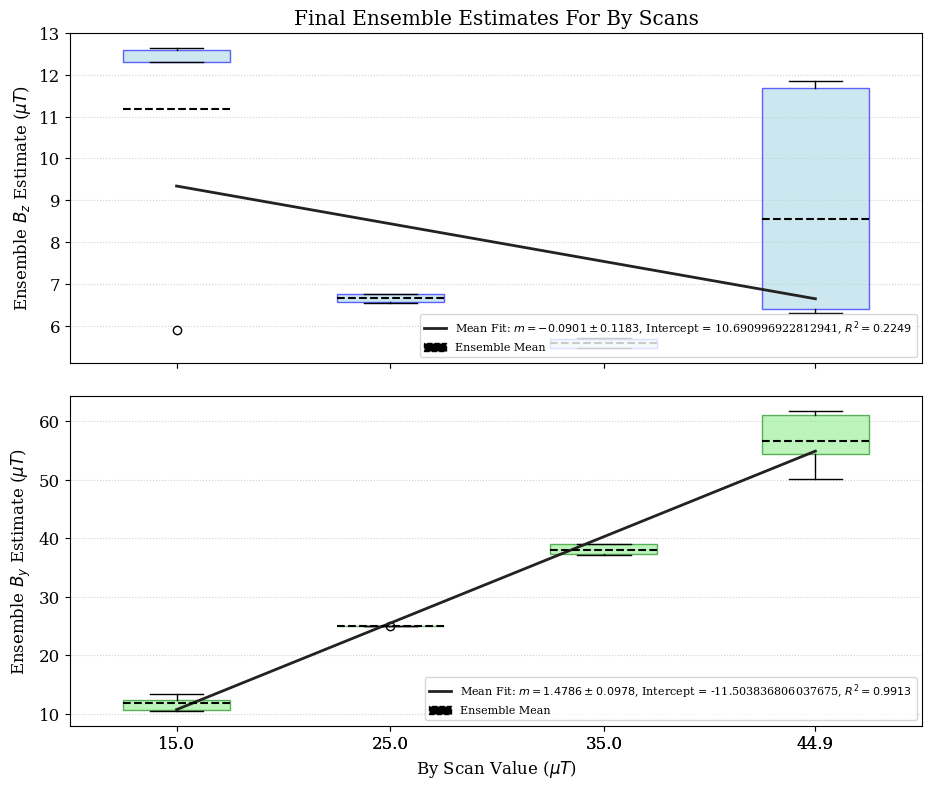

In [46]:
est_first = True
sigma_noise = 0.4
prior = 2.0
save_path = f"Results\\Dataset_10\\03_June\\Prior_Test_{prior}\\Linear_Interpolation\\Est_First_Z_{est_first}\\Gaussian_Likelihood\\Sigma_{sigma_noise}\\Final_Estimates_Ensemble_Averages.png"
os.makedirs(f"Results\\Dataset_10\\03_June\\Prior_Test_{prior}\\Linear_Interpolation\\Est_First_Z_{est_first}\\Gaussian_Likelihood\\Sigma_{sigma_noise}", exist_ok=True)
# save_path = f"Results\\Dataset_8_Updated\\4_Apr\\Start_Time_Tests\\By_{k}\\Final_Estimates__Ensemble_Averages_v1.png"
est_dict_z, est_dict_y = {}, {}
x_pos = [0.150, 0.250, 0.350, 0.449] 
x_pos = [x*100 for x in x_pos]
for i in range(0,4):
    bz_final_map, by_final_map = [], []
    for j in range(0, 10,2):
        curr_time = 15.0 + j
        directory = f"D:\\Pranav_and_Dinesh\\Dinesh\\Results\\Dataset_10\\03_June\\Prior_Test_{prior}\\Linear_Interpolation\\Est_First_Z_{est_first}\\Gaussian_Likelihood\\Sigma_{sigma_noise}\\Test_{j//2}_Dataset_10_By_{i}_from_{curr_time}_microseconds_Randomised_Start_Time_Sigma_noise_{sigma_noise}"
        # directory = f"Results\\Dataset_8_Updated\\4_Apr\\Start_Time_Tests\\Test_{j//2}_Dataset_8_By_{i}_from_{curr_time}_microseconds_0.2_step_Adaptive_Bias_Selection_Fixed_Estimate_Marginalisation_1_sigma"
        result_longitudinal_list = sorted([
                os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_12_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_13_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_14_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_15_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_11_06_2026_")) and f.endswith(r".npz")
            ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))
        result_transverse_list = sorted([
                os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_12_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_13_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_14_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_15_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_11_06_2026_")) and f.endswith(r".npz")
            ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))

        # result_longitudinal_list = sorted([
        #         os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_04_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_05_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_06_04_2026_")) and f.endswith(r".npz")
        #     ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))
        # result_transverse_list = sorted([
        #         os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_04_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_05_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_06_04_2026_")) and f.endswith(r".npz")
        #     ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))
    

        longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
        transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]
        # print(len(longitudinal_estimation_results), len(transverse_field_estimation_results))
        bz_final_estimate = []
        by_final_estimate = []
        #est_first_z is true, so we are following this logic -> len(transverse) and longitudinal[k+1], for false, its opposite
        if est_first:
             for k in range(len(transverse_field_estimation_results)-1):
                bz_final_estimate.append(longitudinal_estimation_results[k+1]["est"][-1]/0.7*100)
                by_final_estimate.append(transverse_field_estimation_results[k]["est"][-1]/0.7*100)
        else:
            for k in range(len(longitudinal_estimation_results)):
                bz_final_estimate.append(longitudinal_estimation_results[k]["est"][-1]/0.7*100)
                by_final_estimate.append(transverse_field_estimation_results[k+1]["est"][-1]/0.7*100)

        bz_final_map.append(bz_final_estimate[-1]); by_final_map.append(by_final_estimate[-1])

    est_dict_z[f'{x_pos[i]:.6e}'] = bz_final_map
    est_dict_y[f'{x_pos[i]:.6e}'] = by_final_map
plot_temporal_ensemble_boxplot( est_dict_z, est_dict_y, x_pos, save_path=save_path)

Compare Frequenist and Bayesian Plots

In [47]:
def benchmarking_attempt_1(x_pos, by_final_freq_means, by_final_freq_stds, bz_final_freq_means, bz_final_freq_stds, by_final_bayes_means, by_final_bayes_stds, bz_final_bayes_means, bz_final_bayes_stds, save_path=None):
    x_pos, by_final_freq_means, by_final_freq_stds, bz_final_freq_means, bz_final_freq_stds = np.array(x_pos), np.array(by_final_freq_means), np.array(by_final_freq_stds), np.array(bz_final_freq_means), np.array(bz_final_freq_stds)
    x_pos, by_final_bayes_means, by_final_bayes_stds, bz_final_bayes_means, bz_final_bayes_stds = np.array(x_pos), np.array(by_final_bayes_means), np.array(by_final_bayes_stds), np.array(bz_final_bayes_means), np.array(bz_final_bayes_stds)
    fig, (ax_z, ax_y) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
    # ax_z.axhline(true_bz_background, color='gray', linestyle='--', alpha=0.7, label='Nominal $B_z$ Background')
    
    res_freq_z = linregress(x_pos, bz_final_freq_means)
    res_freq_y = linregress(x_pos, by_final_freq_means)
    res_bayes_z = linregress(x_pos, bz_final_bayes_means)
    res_bayes_y = linregress(x_pos, by_final_bayes_means)
    
    ax_z.errorbar(x_pos, bz_final_freq_means, yerr=bz_final_freq_stds, 
              fmt='o', capsize=5, color='tab:red', label='Frequentist', alpha=0.8)
    ax_z.errorbar(x_pos + 0.005, bz_final_bayes_means, yerr=bz_final_bayes_stds, 
              fmt='s', capsize=5, color='tab:blue', label='Adaptive Bayesian (Ensemble)', alpha=0.8)
    ax_z.set_ylabel('Estimated $B_z$ ($\mu$T)', fontsize=12)
    ax_z.set_title('Estimation Precision under 111-Field Scans', fontsize=14)
    ax_z.grid(True, linestyle=':', alpha=0.6)
    

    # --- Linear Fit Overlays ---
    x_line = np.linspace(min(x_pos), max(x_pos), 100)
    
    fit_label_freq_z = rf'Freq Mean Fit: $m={res_freq_z.slope:.4f} \pm {res_freq_z.stderr:.4f}$, Intercept = {res_freq_z.intercept}, $R^2={res_freq_z.rvalue**2:.4f}$'
    fit_line_freq_z, = ax_z.plot(x_line, res_freq_z.slope * x_line + res_freq_z.intercept, '-', color="#E92424", linewidth=2, label=fit_label_freq_z)

    fit_label_freq_y = rf'Freq Mean Fit: $m={res_freq_y.slope:.4f} \pm {res_freq_y.stderr:.4f}$, Intercept = {res_freq_y.intercept}, $R^2={res_freq_y.rvalue**2:.4f}$'
    fit_line_freq_y, = ax_y.plot(x_line, res_freq_y.slope * x_line + res_freq_y.intercept, '-', color="#D62B2B", linewidth=2, label=fit_label_freq_y)

    fit_label_bayes_z = rf'Bayes Mean Fit: $m={res_bayes_z.slope:.4f} \pm {res_bayes_z.stderr:.4f}$, Intercept = {res_bayes_z.intercept}, $R^2={res_bayes_z.rvalue**2:.4f}$'
    fit_line_bayes_z, = ax_z.plot(x_line, res_bayes_z.slope * x_line + res_bayes_z.intercept, '-', color="#242121", linewidth=2, label=fit_label_bayes_z)

    fit_label_bayes_y = rf'Bayes Mean Fit: $m={res_bayes_y.slope:.4f} \pm {res_bayes_y.stderr:.4f}$, Intercept = {res_bayes_y.intercept}, $R^2={res_bayes_y.rvalue**2:.4f}$'
    fit_line_bayes_y, = ax_y.plot(x_line, res_bayes_y.slope * x_line + res_bayes_y.intercept, '-', color="#242121", linewidth=2, label=fit_label_bayes_y)
    ax_z.legend(loc='best', fontsize=7)

    ax_y.plot(x_pos, x_pos, color='gray', linestyle='--', alpha=0.7, label='Ideal Calibration Curve ($y=x$)')
    ax_y.errorbar(x_pos - 0.005, by_final_freq_means, yerr=by_final_freq_stds, 
                fmt='o', capsize=5, color='tab:red', label='Frequentist', alpha=0.8)
    ax_y.errorbar(x_pos + 0.005, by_final_bayes_means, yerr=by_final_bayes_stds, 
                fmt='s', capsize=5, color='tab:blue', label='Adaptive Bayesian (Ensemble)', alpha=0.8)
    ax_y.set_xlabel('Applied $B_y$ Scan Value ($\mu$T)', fontsize=12)
    ax_y.set_ylabel('Estimated $B_y$ ($\mu$T)', fontsize=12)
    ax_y.set_xticks(x_pos)
    ax_y.grid(True, linestyle=':', alpha=0.6)
    ax_y.legend(loc='best', fontsize=7)
    
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=300)
    plt.show()
    pass

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_26308\526962972.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax_z.set_ylabel('Estimated $B_z$ ($\mu$T)', fontsize=12)
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_26308\526962972.py:42: SyntaxWarning: invalid escape sequence '\m'
  ax_y.set_xlabel('Applied $B_y$ Scan Value ($\mu$T)', fontsize=12)
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_26308\526962972.py:43: SyntaxWarning: invalid escape sequence '\m'
  ax_y.set_ylabel('Estimated $B_y$ ($\mu$T)', fontsize=12)


[np.float64(11.168674000389483), np.float64(6.658063965230362), np.float64(5.5891827981573226), np.float64(8.542615747322646)] 
 [np.float64(2.6388771846932277), np.float64(0.0896134218332178), np.float64(0.09835963776790232), np.float64(2.6369046123530957)] 
 [np.float64(11.761828733692832), np.float64(24.961817596378083), np.float64(37.96431093256174), np.float64(56.57657615112161)] 
 [np.float64(1.0900929604336045), np.float64(0.028174217476161813), np.float64(0.8444827962462791), np.float64(4.361546937115277)]
[8.485714285714288, 7.7714285714285705, 6.4, 7.514285714285715] 
 [np.float64(0.7876599286908698), np.float64(1.3317167070195906), np.float64(2.470230923684369), np.float64(3.6589281356759136)] 
 [14.700000000000003, 30.28571428571429, 45.0, 69.42857142857143] 
 [np.float64(0.49897854847351375), np.float64(1.0192033703849697), np.float64(2.0454030090394792), np.float64(2.751622897751175)]


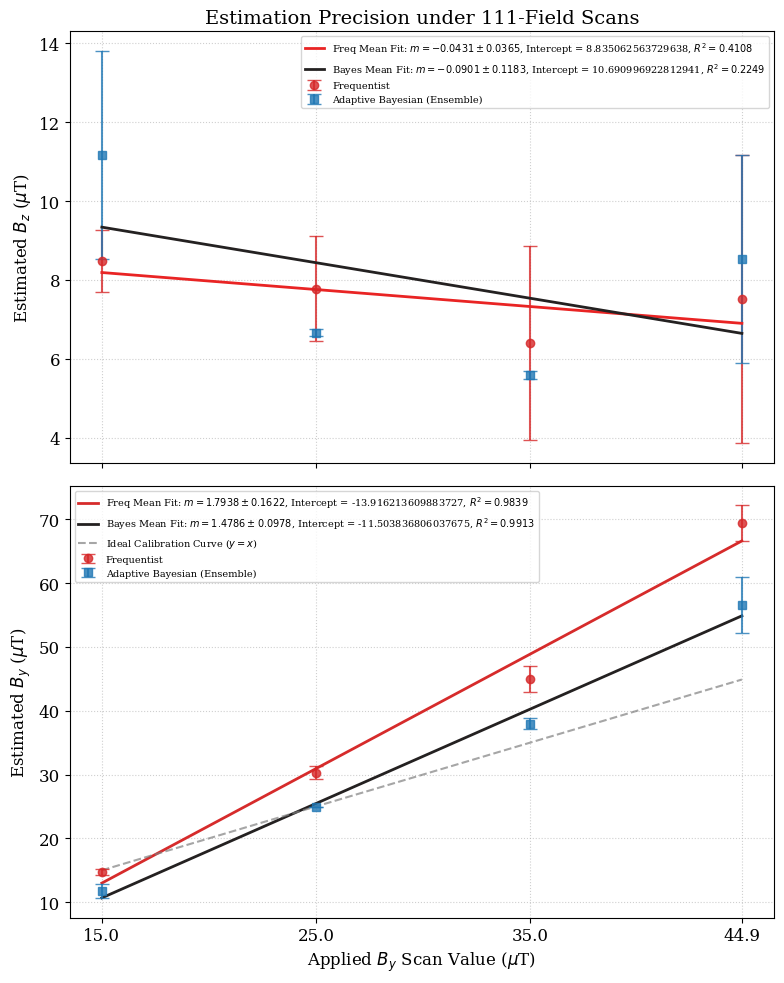

In [52]:
est_first = True
sigma_noise = 0.4
prior = 2.0
save_path = f"Results\\Dataset_10\\03_June\\Prior_Test_{prior}\\Linear_Interpolation\\Est_First_Z_{est_first}\\Gaussian_Likelihood\\Sigma_{sigma_noise}\\Benchmarking_Attempt_1.png"
# save_path = f"Results\\Dataset_8_Updated\\4_Apr\\Start_Time_Tests\\By_{k}\\Final_Estimates__Ensemble_Averages_v1.png"
est_dict_z, est_dict_y = {}, {} #we do not technically need this
x_pos = [0.150, 0.250, 0.350, 0.449] 
x_pos = [x*100 for x in x_pos]
by_final_freq_means, by_final_freq_stds = [0.1029/0.7*100, 0.2120/0.7*100, 0.315/0.7*100, 0.486/0.7*100], [np.sqrt(1.22e-5)/0.7*100, np.sqrt(5.09e-5)/0.7*100, np.sqrt(2.05e-4)/0.7*100, np.sqrt(3.71e-4)/0.7*100]
bz_final_freq_means, bz_final_freq_stds = [0.0594/0.7*100, 0.0544/0.7*100, 0.0448/0.7*100, 0.0526/0.7*100], [np.sqrt(3.04e-5)/0.7*100, np.sqrt(8.69e-5)/0.7*100, np.sqrt(2.99e-4)/0.7*100, np.sqrt(6.56e-4)/0.7*100]
by_final_bayes_means, by_final_bayes_stds = [], []
bz_final_bayes_means, bz_final_bayes_stds = [], []
for i in range(0,4):
    bz_final_map, by_final_map = [], []
    for j in range(0, 10,2):
        curr_time = 15.0 + j
        directory = f"D:\\Pranav_and_Dinesh\\Dinesh\\Results\\Dataset_10\\03_June\\Prior_Test_{prior}\\Linear_Interpolation\\Est_First_Z_{est_first}\\Gaussian_Likelihood\\Sigma_{sigma_noise}\\Test_{j//2}_Dataset_10_By_{i}_from_{curr_time}_microseconds_Randomised_Start_Time_Sigma_noise_{sigma_noise}"
        # directory = f"Results\\Dataset_8_Updated\\4_Apr\\Start_Time_Tests\\Test_{j//2}_Dataset_8_By_{i}_from_{curr_time}_microseconds_0.2_step_Adaptive_Bias_Selection_Fixed_Estimate_Marginalisation_1_sigma"
        result_longitudinal_list = sorted([
                os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_03_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_12_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_13_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_14_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_15_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_11_06_2026_")) and f.endswith(r".npz")
            ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))
        result_transverse_list = sorted([
                os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_03_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_12_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_13_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_14_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_15_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_11_06_2026_")) and f.endswith(r".npz")
            ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))

        # result_longitudinal_list = sorted([
        #         os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_04_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_05_04_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_06_04_2026_")) and f.endswith(r".npz")
        #     ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))
        # result_transverse_list = sorted([
        #         os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_04_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_05_04_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_06_04_2026_")) and f.endswith(r".npz")
        #     ], key=lambda x: float(x.split(r"_04_2026_")[1].split(r".npz")[0]))
    

        longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
        transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]
        bz_final_estimate = []
        by_final_estimate = []
        if est_first:
            for k in range(len(transverse_field_estimation_results)-1):
                bz_final_estimate.append(longitudinal_estimation_results[k+1]["est"][-1]/0.7*100)
                by_final_estimate.append(transverse_field_estimation_results[k]["est"][-1]/0.7*100)
        else:
            for k in range(len(longitudinal_estimation_results)):
                bz_final_estimate.append(longitudinal_estimation_results[k]["est"][-1]/0.7*100)
                by_final_estimate.append(transverse_field_estimation_results[k+1]["est"][-1]/0.7*100)

        bz_final_map.append(bz_final_estimate[-1]); by_final_map.append(by_final_estimate[-1])
    est_dict_z[f'{x_pos[i]:.6e}'] = bz_final_map
    est_dict_y[f'{x_pos[i]:.6e}'] = by_final_map
    by_final_bayes_means.append(np.mean(by_final_map))
    by_final_bayes_stds.append(np.std(by_final_map))
    bz_final_bayes_means.append(np.mean(bz_final_map))
    bz_final_bayes_stds.append(np.std(bz_final_map))
print(bz_final_bayes_means, "\n",bz_final_bayes_stds,"\n", by_final_bayes_means,"\n", by_final_bayes_stds)
print(bz_final_freq_means, "\n",bz_final_freq_stds,"\n", by_final_freq_means,"\n", by_final_freq_stds)
benchmarking_attempt_1(x_pos, by_final_freq_means, by_final_freq_stds, bz_final_freq_means, bz_final_freq_stds, by_final_bayes_means, by_final_bayes_stds, bz_final_bayes_means, bz_final_bayes_stds, save_path=save_path)

In [ ]:
sigma = np.linspace(0.1,0.7, 20)
sigma = np.concatenate([sigma, np.arange(0.7, 0.9, 0.03157894736842107)[1:]])
print(sigma)

Result vs Sigma - Gaussian Case

I restrict myself to By_0 scan right now

In [ ]:
sigma = np.linspace(0.1,0.7, 20)
sigma = np.concatenate([sigma, np.arange(0.7, 0.9, 0.03157894736842107)[1:]])

for i in range(0,4):
    by_final_bayes_means, by_final_bayes_stds, bz_final_bayes_means, bz_final_bayes_stds = [], [], [], []
    for sigma_noise in sigma:
        bz_final_map, by_final_map = [], []
        for j in range(0, 10,2):
            curr_time = 15.0 + j
            directory = f"D:\\Pranav_and_Dinesh\\Dinesh\\Results\\Dataset_10\\24_May\\Linear_Interpolation\\Est_First_Z_False\\Gaussian_Likelihood\\Sigma_{sigma_noise}\\Test_{j//2}_Dataset_10_By_{i}_from_{curr_time}_microseconds_Randomised_Start_Time_Sigma_noise_{sigma_noise}"
            # directory = f"Results\\Dataset_8_Updated\\4_Apr\\Start_Time_Tests\\Test_{j//2}_Dataset_8_By_{i}_from_{curr_time}_microseconds_0.2_step_Adaptive_Bias_Selection_Fixed_Estimate_Marginalisation_1_sigma"
            if sigma_noise <= 0.7:
                if i != 0:
                    result_longitudinal_list = sorted([
                            os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_28_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                        ], key=lambda x: float(x.split(r"_05_2026_")[1].split(r".npz")[0]))
                    result_transverse_list = sorted([
                            os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_28_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                        ], key=lambda x: float(x.split(r"_05_2026_")[1].split(r".npz")[0]))   
                else:
                    result_longitudinal_list = sorted([
                        os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_24_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_28_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                    ], key=lambda x: float(x.split(r"_05_2026_")[1].split(r".npz")[0]))
                    result_transverse_list = sorted([
                        os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_24_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_28_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                        ], key=lambda x: float(x.split(r"_05_2026_")[1].split(r".npz")[0]))
            else:
                if i != 0:
                    result_longitudinal_list = sorted([
                            os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_02_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_01_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                        ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))
                    result_transverse_list = sorted([
                            os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_02_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_01_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                        ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))   
                else:
                    result_longitudinal_list = sorted([
                        os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_02_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_01_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                    ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))
                    result_transverse_list = sorted([
                        os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_02_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_01_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_9_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
                        ], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))

            longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
            transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]
            # print(len(longitudinal_estimation_results), len(transverse_field_estimation_results))
            bz_final_estimate = []
            by_final_estimate = []
            if False:
                for k in range(len(transverse_field_estimation_results)-1):
                    bz_final_estimate.append(longitudinal_estimation_results[k+1]["est"][-1]/0.7*100)
                    by_final_estimate.append(transverse_field_estimation_results[k]["est"][-1]/0.7*100)
            else:
                for k in range(len(longitudinal_estimation_results)):
                    bz_final_estimate.append(longitudinal_estimation_results[k]["est"][-1]/0.7*100)
                    by_final_estimate.append(transverse_field_estimation_results[k+1]["est"][-1]/0.7*100)

            bz_final_map.append(bz_final_estimate[-1]); by_final_map.append(by_final_estimate[-1])
        by_final_bayes_means.append(np.mean(by_final_map))
        by_final_bayes_stds.append(np.std(by_final_map))
        bz_final_bayes_means.append(np.mean(bz_final_map))
        bz_final_bayes_stds.append(np.std(bz_final_map))
    print(len(bz_final_bayes_stds), len(by_final_bayes_stds))
    print(bz_final_bayes_stds)

    plt.figure(figsize=(10, 8))
    plt.subplot(2,1, 1)
    plt.plot(sigma, by_final_bayes_means, label='By Bayes Mean', marker='.', markersize=3)
    plt.errorbar(sigma, np.array(by_final_bayes_means), yerr=np.array(by_final_bayes_stds), alpha=0.2, capsize=5)
    plt.axhline(by_final_freq_means[i], label='By Frequentist Mean', marker='.', markersize=3)
    plt.fill_between(sigma, np.full(len(sigma), by_final_freq_means[i]) - np.array(by_final_freq_stds[i]), np.full(len(sigma), by_final_freq_means[i]) + np.array(by_final_freq_stds[i]), color='blue', alpha=0.1)
    plt.legend(loc = 'best')
    plt.ylabel('Estimated Field $B_y$ ($\mu$T)')
    plt.subplot(2,1, 2)
    plt.plot(sigma, bz_final_bayes_means, label='Bz Bayes Mean', marker='.', markersize=3)
    plt.errorbar(sigma, np.array(bz_final_bayes_means), yerr=np.array(bz_final_bayes_stds), alpha=0.2, capsize=5)
    plt.axhline(bz_final_freq_means[i], label='Bz Frequentist Mean', marker='.', markersize=3)
    plt.xlabel('Sigma of Likelihood, $\sigma$')
    plt.ylabel('Estimated Field $B_z$ ($\mu$T)')
    plt.fill_between(sigma, np.full(len(sigma), bz_final_freq_means[i]) - np.array(bz_final_freq_stds[i]), np.full(len(sigma), bz_final_freq_means[i]) + np.array(bz_final_freq_stds[i]), color='blue', alpha=0.1)
    plt.legend(loc = 'best')
    plt.show()

In [ ]:
i  = 3
sigma_noise = 0.4
j = 8
curr_time = 15.0 + j
prior = 1.0
directory = f"D:\\Pranav_and_Dinesh\\Dinesh\\Results\\Dataset_10\\03_June\\Prior_Test_{prior}\\Linear_Interpolation\\Est_First_Z_False\\Gaussian_Likelihood\\Sigma_{sigma_noise}\\Test_{j//2}_Dataset_10_By_{i}_from_{curr_time}_microseconds_Randomised_Start_Time_Sigma_noise_{sigma_noise}"
result_longitudinal_list = sorted([
    os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_03_06_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"longitudinal_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))
result_transverse_list = sorted([
    os.path.join(directory, f) for f in os.listdir(directory) if (f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_03_06_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_25_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_26_05_2026_") or f.startswith(f"transverse_field_estimation_results_Dataset_10_Starting with{curr_time} us_T Step 0.2 us_plus_0.0_initial estimate_27_05_2026_")) and f.endswith(r".npz")
], key=lambda x: float(x.split(r"_06_2026_")[1].split(r".npz")[0]))

print(len(result_longitudinal_list))

longitudinal_estimation_results = [np.load(f, allow_pickle=True) for f in result_longitudinal_list]
transverse_field_estimation_results = [np.load(f, allow_pickle=True) for f in result_transverse_list]

time = transverse_field_estimation_results[8]["time"]
print(time)

Histogram Plot for Convergence Accuracy and Start Time  

In [ ]:
# def plot_convergence_histogram(start_times, total_converged, correctly_converged, save_path=None):
#     fig, ax = plt.subplots(figsize=(10, 6))

#     x = np.arange(len(start_times))  # Label locations
#     width = 0.3  # Width of the bars

#     x_didnt_converge = []
#     total_didnt_converge = []
#     didnt_converge = np.where(np.asarray(total_converged) >= 15, True, False)
#     print(len(didnt_converge))
#     if len(didnt_converge) >0: 
#         for i in range(len(didnt_converge)):
#             if didnt_converge[i]:
#                 x_didnt_converge.append(x[i])
#                 total_didnt_converge.append(total_converged[i])
#     else:
#         x_didnt_converge = []
#         total_didnt_converge = []

#     x_correct_didnt_converge = []
#     total_correct_didnt_converge = []
#     didnt_correct_converge = np.where(np.asarray(correctly_converged) >= 15, True, False)
#     print(len(didnt_correct_converge))
#     if len(didnt_correct_converge) >0: 
#         for i in range(len(didnt_correct_converge)):
#             if didnt_correct_converge[i]:
#                 x_correct_didnt_converge.append(x[i])
#                 total_correct_didnt_converge.append(correctly_converged[i])
#     else:
#         x_correct_didnt_converge = []
#         total_correct_didnt_converge = []

#     # Plot the two sets of bars side-by-side by shifting their x-positions
#     rects1 = ax.bar(x - width/2, total_converged, width, label='Converged', color='gray')
#     rects1wrong = ax.bar(np.asarray(x_didnt_converge)-width/2, total_didnt_converge, width, label='Did Not Converge', color='red')
#     rects2 = ax.bar(x + width/2, correctly_converged, width, label='Y Estimate Converged Correctly', color='green')
#     rects2wrong = ax.bar(np.asarray(x_correct_didnt_converge)+width/2, total_correct_didnt_converge, width, label='Y Estimate Did Not Converge Correctly', color='black')

#     ax.set_xlabel(r'Estimation Start Time ($\mu$s)')
#     ax.set_ylabel('Number of Experiments')
#     ax.set_title('Algorithmic Convergence vs. Physical Accuracy for By = 0.25 G scan')
#     ax.set_xticks(x)
#     ax.set_xticklabels(start_times)
#     ax.set_ylim(0, 15)
#     ax.legend()

#     ax.grid(True, axis='y', linestyle=':', alpha=0.6)
#     plt.tight_layout()
#     if save_path: plt.savefig(save_path, dpi=300)
#     plt.show()

In [ ]:
# start_times = [35.0, 37.0, 39.0, 41.0, 43.0, 45.0]
# total_converged = [15,12, 15, 15,15,14]
# correctly_converged = [2,2, 2, 2,14,2]
# save_path = f"Results\\Dataset_8_Updated\\16_Apr\\Dynamic_Prior_Test\\By_2\\Convergence_Histogram_By_2_Y_Estimate.png"
# plot_convergence_histogram(start_times, total_converged, correctly_converged, save_path=save_path)

# start_times = [35.0, 37.0, 39.0, 41.0, 43.0, 45.0]
# total_converged = [15,15, 15, 15,15,3]
# correctly_converged = [2,2, 2, 2,2,2]
# save_path = f"Results\\Dataset_8_Updated\\16_Apr\\Dynamic_Prior_Test\\By_3\\Convergence_Histogram_By_3_Y_Estimate.png"
# plot_convergence_histogram(start_times, total_converged, correctly_converged, save_path=save_path)

Plotting Individual Results - Older Stuff

In [ ]:
results = np.load(r"Results\Dataset_9\19_May\Linear_Interpolation\Est_First_Z_False\Gaussian_Likelihood\Sigma_0.5\Test_0_Dataset_9_By_0_from_15.0_microseconds_Randomised_Start_Time_sigma_noise_0.5\transverse_field_estimation_results_Dataset_9_Starting with15.0 us_T Step 0.2 us_plus_0.0_initial estimate_20_05_2026_01_01_58.npz", allow_pickle=True)
posteriors = results["posteriors"]
print(results["time"][0])
# final_posterior = posteriors[-1]
# print(est[-1], stddev[-1])
# area = np.trapezoid(final_posterior, x = bgrid[-1])
# print(f"Final posterior area (should be ~1): {area:.6f}")

# plt.figure(figsize=(6, 4))
# plt.plot(bgrid[-1], final_posterior, label="final posterior", marker = '.')
# plt.xlabel("B")
# plt.ylabel("Density")
# plt.title("Posterior after adaptive experiment")
# plt.legend()
# plt.axvline(
#     bgrid[-1][np.argmax(final_posterior)],
#     color="green",
#     linestyle="--",
#     label="MAP Estimate",
# )
# plt.show()

Gif: Posterior

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Magnetic Field B")
ax.set_ylabel("Posterior Probability")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = bgrid[frame]
    y = posteriors[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Posterior Step {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(posteriors), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Test_{Test}/posterior_evolution.gif', writer='pillow', fps=4)

plt.show()

Gif: KL Divergence

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Bias Field")
ax.set_ylabel("Expected KL Divergence")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    f_index_1 = np.where(f_bias_axis > f_sim[10])[0][0]
    f_index_2 = np.where(f_bias_axis > f_sim[-10])[0][0]
    x = f_bias_axis[f_index_1:f_index_2]
    y = expectedkl[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Expected_KL {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(expectedkl), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Test_{Test}/KL_Divergence.gif', writer='pillow', fps=4)

plt.show()

Mode and Std Dev Convergence

In [ ]:
save_path = os.path.join(new_dir, f'Mode Convergence MAP Test {Test}.png'.format(Test))
plt.plot(t, est, label=f"Mode Convergence", marker = '.')
plt.xlabel("Time (microseconds)")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir, f'Std Convergence MAP Test {Test}.png'.format(Test))
plt.plot(t, stddev, label=f"Standard Deviation Convergence", marker = '.')
plt.xlabel("Time (microseconds)")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


Ok, Y field estimation by interpolation test.... First we'll have a look at the datasets together and try an interpolation method, measure accuracy and then try the same estimation procedure. 

In [ ]:
t_sim, f_sim, by_sim, sim_cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)

In [ ]:
# interact(plot_slice, by_idx=IntSlider(min=0, max=len(by_sim)-1, step=1, value=0));

Okay, here we validate the interpolation method. The logic is to check for measure of good fit by leaving a point out in each iteration and extrapolating its value from the rest and seeing how well the prediction is. An average is taken over each such iteration corresponding to each point in the domain.

In [ ]:
# validate_interpolator(t_sim, f_sim, by_sim, sim_cube)

In [ ]:
t_sim, f_sim, by_sim,sim_interp = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation)

Plotting Interpolator Predictions

In [ ]:
y_vals = np.linspace(0, 0.5, 10)
Z_mesh, Y_mesh = np.meshgrid(f_sim, y_vals, indexing='ij')
T_mesh = np.full_like(Z_mesh, t_sim[-1])
query_points = np.stack((T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()), axis=1)
predictions = sim_interp(query_points)
predictions = predictions.reshape(Z_mesh.shape)

plt.figure(figsize=(10,10))
for i in range(len(y_vals)):
    plt.plot(f_sim, predictions[:,i], label=f'Y_val {float(y_vals[i])}', marker = '.')
    plt.ylabel("Normalised Intensity")
    plt.xlabel("Longitudinal Field")
    if i%5==0: plt.legend()
    plt.title("Interpolator Predictions at Final Time Slice, steady state")
plt.show()

In [ ]:
y_vals = np.linspace(0, 0.5, 100)
Z_mesh, Y_mesh = np.meshgrid(f_sim[np.argmax(sim_cube[-1,:,0])], y_vals, indexing='ij')
T_mesh = np.full_like(Z_mesh, t_sim[-1])
query_points = np.stack((T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()), axis=1)
predictions = sim_interp(query_points)
predictions = predictions.reshape(Z_mesh.shape)

plt.plot(y_vals, predictions[0,:], label=f'Y_val{float(y_vals[i])}', marker = '.')
plt.ylabel("Normalised Intensity")
plt.xlabel("Transverse Y Field")
plt.title("Interpolator Predictions at Final Time Slice for fixed Longitudinal Field ~0")
plt.show()

Transverse Field Estimation for Various Time Steps - Minor Modifications to the code to save files appropriately are required - 18/01/2026

In [ ]:
'''t_step = [i/10 for i in range(5, 100, 5)]
for T_STEP in t_step:
    MAX_TIME = 30
    if T_STEP>=1:
        zoom_factor = ZOOM_FACTOR**(T_STEP**0.5)
    results_y_estimation = run_experiment_y_estimation(fixed_bz_estimate = 0.12, curr_time = 0, zoom_factor = zoom_factor)
    t,est,stddev,bias,res,posteriors,bgrid,expectedkl = results_y_estimation['time'], results_y_estimation['est'],results_y_estimation['stddev'], results_y_estimation['bias'], results_y_estimation['res'], results_y_estimation['posteriors'], results_y_estimation['bgrids'], results_y_estimation['expectedkl']
    result_y_estimation = {
    'time':np.array(t), 
    'est':np.array(est), 
    'stddev':np.array(stddev), 
    'bias':np.array(bias), 
    'res':np.array(res), 
    'posteriors':np.array(posteriors, dtype=object), 
    'bgrids':np.array(bgrid, dtype=object), 
    'expectedkl':np.array(expectedkl, dtype=object)
    }
    np.savez_compressed(f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Test_{Test}_results_y_estimation_T_STEP_{T_STEP}.npz", **result_y_estimation)
    print(f"Results for t_step {T_STEP} saved successfully.")
print("results saved succcesfully")'''

Loading Results for the transverse estimation - Please verify test variable value and the address in np.load to ensure the right result is loaded

In [ ]:
T_STEP = 0.2
result_longitudinal_estimation = np.load(f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Test_{Test}_results_y_estimation.npz", allow_pickle=True)
t,est,stddev,bias,res,posteriors,bgrid,expectedkl = result_longitudinal_estimation['time'], result_longitudinal_estimation['est'],result_longitudinal_estimation['stddev'], result_longitudinal_estimation['bias'], result_longitudinal_estimation['res'], result_longitudinal_estimation['posteriors'], result_longitudinal_estimation['bgrids'], result_longitudinal_estimation['expectedkl']
print("Results data loaded successfully.")
exp_trace_0 = exp_matrix[:,0].flatten()
print(exp_trace_0.shape)
t_exp_0, __ = find_pulse_start(exp_trace_0, t_exp, EXP_PULSE_THRESH)
plot_heat_and_surface((t_exp[__:]-t_exp_0), f_bias_axis, exp_matrix[__:,], trajectory_mode=True,traj_bias = bias, title_prefix="Bias Z Trajectory_Transverse")

In [ ]:
final_posterior = posteriors[-1]
print(est[-1], stddev[-1])
area = np.trapezoid(final_posterior, x = bgrid[-1])
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(bgrid[-1][np.argmax(final_posterior) - 1000:np.argmax(final_posterior)+1000], final_posterior[np.argmax(final_posterior) - 1000:np.argmax(final_posterior)+1000], label="final posterior", marker = '.')
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(
    bgrid[-1][np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

Posterior GIF

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Transverse Magnetic Field B")
ax.set_ylabel("Posterior Probability")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = bgrid[frame]
    y = posteriors[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Posterior Step {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(posteriors), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_field_posterior_evolution.gif', writer='pillow', fps=4)

plt.show()

KL Divergence GIF

In [ ]:
# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Bias Field")
ax.set_ylabel("Expected KL Divergence")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = f_bias_axis[2:-1]
    y = expectedkl[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Expected_KL {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(expectedkl), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_Field_KL_Divergence.gif', writer='pillow', fps=4)

plt.show()

Summary Stats

In [ ]:
save_path = os.path.join(new_dir_y, f'Mode Convergence MAP Transverse Field.png'.format(Test))
plt.plot(t, est, label=f"Mode Convergence")
plt.xlabel("Time (microseconds)")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir_y, f'Std Convergence MAP Transverse Field.png'.format(Test))
plt.plot(t, stddev, label=f"Standard Deviation Convergence")
plt.xlabel("Time (microseconds)")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


In [ ]:
def altopt(num_iter = 5, max_time=30, curr_time = 0,t_step=0.2, tol_bz=1e-4, tol_by=1e-4, patience=2, Est_First_Z = True):
    
    global MAX_TIME, T_STEP, fixed_bz_estimate, fixed_by_estimate
    old_max_time, old_t_step = MAX_TIME, T_STEP
    MAX_TIME, T_STEP = max_time, t_step
    
    if Est_First_Z:
        try:
            bz_history = []
            by_history = []
            stable_bz_runs = 0
            stable_by_runs = 0
            
            # Initial Bz estimation (start with fixed_by_estimate = 0.0)
            fixed_by_estimate = 0.0
            results = run_experiment_longitudinal_estimation(fixed_by_estimate, curr_time)
            print(results)
            fixed_bz_estimate = results['est'][-1]
            bz_history.append(fixed_bz_estimate)
            print(f"Estimated Bz: {fixed_bz_estimate}")
            
            for i in range(num_iter):
                # Estimate By given current Bz
                results_by = run_experiment_y_estimation(fixed_bz_estimate, curr_time)
                new_by = results_by['est'][-1]
                
                # UPDATE THE GLOBAL BY ESTIMATE
                fixed_by_estimate = new_by

                # Early-stop tracking for By
                if by_history and abs(new_by - by_history[-1]) <= tol_by:
                    stable_by_runs += 1
                else:
                    stable_by_runs = 0
                by_history.append(new_by)
                print(f"Estimated By: {new_by} (stable {stable_by_runs}/{patience})")
                
                # Re-estimate Bz given new By
                results = run_experiment_longitudinal_estimation(new_by, print_plot = False)
                new_bz = results['est'][-1]
                
                # UPDATE THE GLOBAL BZ ESTIMATE
                fixed_bz_estimate = new_bz
                
                # Early-stop tracking for Bz
                if abs(new_bz - bz_history[-1]) <= tol_bz:
                    stable_bz_runs += 1
                else:
                    stable_bz_runs = 0
                bz_history.append(new_bz)
                print(f"Estimated Bz: {new_bz} (stable {stable_bz_runs}/{patience})")
                
                # Check combined early-stop condition
                if (stable_bz_runs >= patience) and (stable_by_runs >= patience):
                    print(f"Early stopping at iteration {i+1}: Bz and By stable for >= {patience} steps (tol_bz={tol_bz}, tol_by={tol_by}).")
                    break
                
            return bz_history, by_history
        finally:
            MAX_TIME, T_STEP = old_max_time, old_t_step
    else:
        try:
            bz_history = []
            by_history = []
            stable_bz_runs = 0
            stable_by_runs = 0
            
            # Initial By estimation (start with fixed_bz_estimate = 0.0)
            fixed_bz_estimate = 0.0
            results = run_experiment_y_estimation(fixed_bz_estimate, curr_time)
            print(results)
            fixed_by_estimate = results['est'][-1]
            by_history.append(fixed_bz_estimate)
            print(f"Estimated By: {fixed_by_estimate}")
            
            for i in range(num_iter):
                # Estimate By given current Bz
                results_bz = run_experiment_longitudinal_estimation(fixed_by_estimate, curr_time)
                new_bz = results_bz['est'][-1]
                
                # UPDATE THE GLOBAL BY ESTIMATE
                fixed_bz_estimate = new_bz

                # Early-stop tracking for By
                if bz_history and abs(new_bz - bz_history[-1]) <= tol_bz:
                    stable_bz_runs += 1
                else:
                    stable_bz_runs = 0
                bz_history.append(new_bz)
                print(f"Estimated By: {new_bz} (stable {stable_bz_runs}/{patience})")
                
                # Re-estimate Bz given new By
                results = run_experiment_y_estimation(new_bz, print_plot = False)
                new_by = results['est'][-1]
                
                # UPDATE THE GLOBAL BZ ESTIMATE
                fixed_by_estimate = new_by
                
                # Early-stop tracking for Bz
                if abs(new_by - by_history[-1]) <= tol_by:
                    stable_by_runs += 1
                else:
                    stable_by_runs = 0
                by_history.append(new_by)
                print(f"Estimated By: {new_by} (stable {stable_by_runs}/{patience})")
                
                # Check combined early-stop condition
                if (stable_bz_runs >= patience) and (stable_by_runs >= patience):
                    print(f"Early stopping at iteration {i+1}: Bz and By stable for >= {patience} steps (tol_bz={tol_bz}, tol_by={tol_by}).")
                    break
                
            return bz_history, by_history
        finally:
            MAX_TIME, T_STEP = old_max_time, old_t_step


def plot_altopt(bz_history, by_history, trajectory_mode=True):
    iterations_bz = list(range(len(bz_history)))
    iterations_by = list(range(len(by_history)))

    plt.figure(figsize=(15, 5))

    # Plot for Bz
    plt.subplot(1, 3, 1)
    plt.plot(iterations_bz, bz_history, marker='o')
    plt.title('Convergence of Bz Estimates')

In [ ]:
results = altopt(num_iter=3, max_time=20, t_step=0.5, tol_bz=1e-4, tol_by=1e-4, patience=2)
bz_history, by_history = results
print("Bz History:", bz_history)
print("By History:", by_history)
plot_altopt(bz_history, by_history)

In [ ]:
plot_altopt(bz_history, by_history, trajectory_mode=True)

In [ ]:
print(bz_history, by_history)

In [ ]:
def test_altopt_sweep(
    t_step_values=[0.2, 0.5, 1.0],
    fixed_by_init_values=[0.0, -0.05, -0.10, -0.12],
    max_time=30,
    num_iter=3,
    tol_bz=1e-4,
    tol_by=1e-4,
    patience=3
):
    """
    Run altopt for different combinations of T_STEP and initial By estimate.
    Returns results dict for plotting.
    """
    results = []
    
    for t_step in t_step_values:
        for by_init in fixed_by_init_values:
            print(f"\n{'='*60}")
            print(f"Testing: T_STEP={t_step}, Initial By={by_init}")
            print(f"{'='*60}")
            
            # Temporarily set the initial estimate
            global fixed_by_estimate
            old_by_estimate = fixed_by_estimate
            fixed_by_estimate = by_init
            
            try:
                bz_hist, by_hist = altopt(
                    num_iter=num_iter,
                    max_time=max_time,
                    t_step=t_step,
                    tol_bz=tol_bz,
                    tol_by=tol_by,
                    patience=patience,
                )
                
                results.append({
                    't_step': t_step,
                    'by_init': by_init,
                    'bz_history': bz_hist,
                    'by_history': by_hist,
                    'label': f'T={t_step}, By₀={by_init}'
                })
                
            except Exception as e:
                print(f"Error with T_STEP={t_step}, By_init={by_init}: {e}")
            finally:
                fixed_by_estimate = old_by_estimate
    
    return results

def plot_altopt_first3_combined(results, save_dir="Tests/Actual/CW/AltOpt"):
    """
    Produce a single combined 3x3 figure:

        Row 1: Bz convergence curves (one per t_step column)
        Row 2: By convergence curves (one per t_step column)
        Row 3: Bz–By trajectory plots (one per t_step column)

    Columns correspond to different t_step values.

    Saves output to Tests/Actual/CW/AltOpt by default.
    """
    from matplotlib.ticker import MaxNLocator

    os.makedirs(save_dir, exist_ok=True)

    # Extract unique t_step values
    t_steps = sorted(set(r["t_step"] for r in results))
    n = len(t_steps)

    # Create 3xN grid
    fig, axes = plt.subplots(3, n, figsize=(7*n, 14))
    fig.suptitle("AltOpt Comparison Across T_STEP Values", fontsize=20)

    # If only 1 t_step, axes will not be 2D; normalize
    if n == 1:
        axes = np.array([axes]).reshape(3, 1)

    for col, t_step in enumerate(t_steps):
        subset = [r for r in results if r["t_step"] == t_step]
        colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(subset)))

        # Unpack row axes
        ax_Bz = axes[0, col]
        ax_By = axes[1, col]
        ax_traj = axes[2, col]

        # Column title
        ax_Bz.set_title(f"T_STEP = {t_step}", fontsize=16)

        # 1. Bz convergence
        for i, res in enumerate(subset):
            it = range(len(res["bz_history"]))
            ax_Bz.plot(it, res["bz_history"], marker="o",
                        color=colors[i], alpha=0.8, label=res["label"])
        ax_Bz.set_xlabel("Iteration")
        ax_Bz.set_ylabel("Bz")
        ax_Bz.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_Bz.grid(True, alpha=0.3)
        ax_Bz.legend(fontsize=7)

        # 2. By convergence
        for i, res in enumerate(subset):
            it = range(len(res["by_history"]))
            ax_By.plot(it, res["by_history"], marker="s",
                        color=colors[i], alpha=0.8, label=res["label"])
        ax_By.set_xlabel("Iteration")
        ax_By.set_ylabel("By")
        ax_By.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_By.grid(True, alpha=0.3)
        ax_By.legend(fontsize=7)

        # 3. Bz–By trajectory
        for i, res in enumerate(subset):
            by_traj = [res["by_init"]] + res["by_history"]
            bz_traj = res["bz_history"]
            ax_traj.plot(bz_traj, by_traj, marker="o", markersize=6,
                         linewidth=2, color=colors[i], alpha=0.8, label=res["label"])
            ax_traj.plot(bz_traj[0], by_traj[0], "x",
                         color=colors[i], markersize=10, markeredgewidth=2)
        ax_traj.set_xlabel("Bz")
        ax_traj.set_ylabel("By")
        ax_traj.grid(True, alpha=0.3)
        ax_traj.legend(fontsize=7)

    plt.tight_layout()

    # Save
    outpath = os.path.join(save_dir, "altopt_first3_combined.png")
    plt.savefig(outpath, dpi=150, bbox_inches="tight")
    print("Saved:", outpath)

    plt.show()


In [ ]:

results = test_altopt_sweep()
plot_altopt_first3_combined(results)

In [ ]:
results = test_altopt_sweep(
    t_step_values=[0.5],
    fixed_by_init_values=[0.5],
    max_time=20,
    num_iter=3,
    tol_bz=5e-5,
    tol_by=5e-5,
    patience=2
)

In [ ]:

bz_test = [0.06260000000000002, 0.06400000000000003, 0.06400000000000003, 0.06400000000000003]

by_test = [0.12625, 0.12625, 0.12625]

plot_altopt(bz_test, by_test)

In [ ]:
T_STEP = 0.2
MAX_TIME = 30
results = run_experiment_longitudinal_estimation(fixed_by_estimate=0.0, curr_time=20.0)

In [ ]:
est, stddev, time_vals = results['est'], results['stddev'], results['time']
save_path = os.path.join(new_dir, f'Mode Convergence Steady State Test {Test}.png'.format(Test))
plt.plot(time_vals, est, label=f"Mode Convergence", marker='.')
plt.xlabel("Time")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Steady State")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir, f'Std Convergence Steady State Test {Test}.png'.format(Test))
plt.plot(time_vals, stddev, label=f"Standard Deviation Convergence", marker='.')
plt.xlabel("Time")
plt.ylabel("Standard Deviation")

In [ ]:
T_STEP = 0.2
MAX_TIME = 30
results = run_experiment_y_estimation(fixed_bz_estimate=0.0, curr_time=20.0)

In [ ]:
est, stddev, time_vals = results['est'], results['stddev'], results['time']
save_path = os.path.join(new_dir, f'Mode Convergence Steady State Test {Test}.png'.format(Test))
plt.plot(time_vals, est, label=f"Mode Convergence", marker='.')
plt.xlabel("Time")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Steady State")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir, f'Std Convergence Steady State Test {Test}.png'.format(Test))
plt.plot(time_vals, stddev, label=f"Standard Deviation Convergence", marker='.')
plt.xlabel("Time")
plt.ylabel("Standard Deviation")

In [ ]:
# Setup figure
posteriors = results['posteriors']
bgrid = results['bgrids']
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Transverse Magnetic Field B")
ax.set_ylabel("Posterior Probability")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = bgrid[frame]
    y = posteriors[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Posterior Step {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(posteriors), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/AltOpt/Test_{Test}/Transverse_field_posterior_evolution.gif', writer='pillow', fps=4)

plt.show()